# Market Making Simulation: Kalshi NBA Markets

## What is this notebook?

This notebook answers a simple question: **can we make money by being the middleman on
Kalshi NBA prediction markets?**

On Kalshi, people bet on NBA outcomes — will the Lakers win? Will LeBron score over 25
points? These bets trade as contracts priced between $0 and $1. A contract at $0.65
means the market thinks there's a 65% chance the event happens.

**Market making** means we continuously offer to buy AND sell these contracts, profiting
from the gap between our buy price and sell price. Think of it like a currency exchange
booth at an airport: they buy euros at $1.08 and sell at $1.12, pocketing the $0.04
difference on every round trip. We do the same thing, but with prediction market contracts.

## The strategy in one sentence

**Post limit orders at the best bid and best ask on Kalshi NBA contracts. When both sides
fill, pocket the spread minus fees.**

## What we measure

1. **Does the spread (buy-sell gap) exceed Kalshi's fees?** If not, stop here.
2. **Adverse selection**: do prices move against us after we get filled? (i.e., are we
   getting picked off by people who know more than us?)
3. **Edge**: the net profit per fill after accounting for spread, adverse selection, and fees.
   Positive edge = we make money on average.
4. **Latency sensitivity**: does this edge survive real-world reaction times, or do we need
   to be faster than everyone else?

## The punchline (spoiler)

Player prop markets (KXNBAPTS -- "will Player X score over Y points?") have wide spreads
($0.04 median), low fees, and positive edge that **survives even 1 second of latency**.
The main risk isn't speed -- it's **inventory accumulation** (NBA bettors overwhelmingly buy
YES, so we end up short). A real strategy needs position limits to manage this.

**Data sources:** `materialized/kalshi_ws/{trade,orderbook_snapshot,orderbook_delta}.parquet`
(1M+ trades, 10M+ book updates, Apr 18-21, 2026).

**Fee model:** Kalshi NBA series -- maker fee = `0.0175 * C * (1-C)` per contract.

In [28]:
import json
import gzip
import re
import io
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

s3 = boto3.client("s3")
S3_BUCKET = "prediction-markets-data"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# --- Fee model (Kalshi NBA series) ---
def kalshi_taker_fee(price):
    return 0.07 * price * (1.0 - price)

def kalshi_maker_fee(price):
    return 0.25 * kalshi_taker_fee(price)

# --- Book reconstruction utilities ---
MIN_SIZE = 0.5  # cents — phantom level cleanup threshold

def book_stats(yes_bk, no_bk):
    """Compute best bid/ask/spread/depth from YES and NO books.
    
    Returns 8-tuple: (best_bid, best_ask, spread, yes_depth, no_depth,
                       bid_depth_top, ask_depth_top, mid)
    ask_depth_top = size at the best NO bid (which IS the YES ask side).
    """
    yes_prices = [(float(p), s) for p, s in yes_bk.items() if s > MIN_SIZE]
    no_prices = [(float(p), s) for p, s in no_bk.items() if s > MIN_SIZE]
    if not yes_prices or not no_prices:
        return None, None, None, 0, 0, 0, 0, None
    best_bid_p, best_bid_sz = max(yes_prices, key=lambda x: x[0])
    best_no_p, best_no_sz = max(no_prices, key=lambda x: x[0])
    best_ask_p = round(1.0 - best_no_p, 4)
    spread = round(best_ask_p - best_bid_p, 4)
    yes_depth = sum(s for _, s in yes_prices)
    no_depth = sum(s for _, s in no_prices)
    mid = (best_bid_p + best_ask_p) / 2
    return best_bid_p, best_ask_p, spread, yes_depth, no_depth, best_bid_sz, best_no_sz, mid

def apply_delta(book, price_key, delta_size):
    new_size = book.get(price_key, 0.0) + delta_size
    if new_size < MIN_SIZE:
        book.pop(price_key, None)
    else:
        book[price_key] = new_size

## 1. Load data

Load all three materialized Parquet files, tag each ticker with its series, and
show the universe we're working with.

In [29]:
# --- Load all three data sources ---
print("Loading materialized Parquet files...")

obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/trade.parquet")
trades_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
trades_df["t_dt"] = pd.to_datetime(trades_df["t_receipt"], unit="s", utc=True)

obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/orderbook_snapshot.parquet")
snap_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))

obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/orderbook_delta.parquet")
delta_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))

print(f"Trades:    {len(trades_df):>12,} rows, {trades_df['ticker'].nunique():>5} tickers")
print(f"Snapshots: {len(snap_df):>12,} rows, {snap_df['ticker'].nunique():>5} tickers")
print(f"Deltas:    {len(delta_df):>12,} rows, {delta_df['ticker'].nunique():>5} tickers")

# Tag each ticker with its series
def get_series(ticker):
    m = re.match(r"(KXNBA\w+?)-", ticker)
    return m.group(1) if m else "unknown"

trades_df["series"] = trades_df["ticker"].apply(get_series)
snap_df["series"] = snap_df["ticker"].apply(get_series)
delta_df["series"] = delta_df["ticker"].apply(get_series)

# Universe summary
print(f"\nTrades by series:")
for series, grp in trades_df.groupby("series"):
    print(f"  {series:15s}: {len(grp):>9,} trades, {grp['ticker'].nunique():>4} tickers")

# Time range
t_min = pd.to_datetime(trades_df["t_receipt"].min(), unit="s", utc=True)
t_max = pd.to_datetime(trades_df["t_receipt"].max(), unit="s", utc=True)
print(f"\nTime range: {t_min} to {t_max}")
print(f"Duration:   {(trades_df['t_receipt'].max() - trades_df['t_receipt'].min()) / 3600:.1f} hours")

Loading materialized Parquet files...
Trades:       1,074,831 rows,   944 tickers
Snapshots:        7,209 rows,  1060 tickers
Deltas:      10,214,186 rows,   845 tickers

Trades by series:
  KXNBAGAME      :   587,767 trades,   62 tickers
  KXNBAPTS       :    52,124 trades,  540 tickers
  KXNBASPREAD    :   232,160 trades,  172 tickers
  KXNBATOTAL     :   202,780 trades,  170 tickers

Time range: 2026-04-19 00:15:13.696224451+00:00 to 2026-04-22 00:38:08.940552950+00:00
Duration:   72.4 hours


### What does our data look like?

We have three data sources from the live WebSocket ingester. Let's look at each one
to understand exactly what we're working with.

**Trades** -- every contract that changed hands on Kalshi during our capture window.
Each row is one trade: who was the aggressor (taker), what price, how many contracts.

**Snapshots** -- a full picture of the order book at the moment we subscribed to each
market. Shows every resting bid and ask at every price level.

**Deltas** -- incremental updates to the order book. Every time someone adds, removes,
or modifies an order, we get a delta. These are the building blocks for reconstructing
the book's state at any point in time.

In [30]:
# --- What does a trade look like? ---
print("TRADE SCHEMA")
print(f"  Shape: {trades_df.shape[0]:,} rows x {trades_df.shape[1]} columns")
print(f"  Columns: {list(trades_df.columns)}\n")
trades_df.head(3)

TRADE SCHEMA
  Shape: 1,074,831 rows x 12 columns
  Columns: ['t_receipt', 'conn_id', 'sid', 'seq', 'ticker', 'yes_price', 'no_price', 'count', 'taker_side', 'ts', 't_dt', 'series']



,t_receipt,conn_id,sid,seq,ticker,yes_price,no_price,count,taker_side,ts,t_dt,series
0,1.776560e+09,NaN,4,39462,KXNBASPREAD-26APR18HOULAL-LAL7,0.33,0.67,0,yes,1776560193,2026-04-19 00:56:33.978653908+00:00,KXNBASPREAD
1,1.776560e+09,NaN,4,39463,KXNBASPREAD-26APR18HOULAL-LAL7,0.33,0.67,0,yes,1776560193,2026-04-19 00:56:33.978673458+00:00,KXNBASPREAD
2,1.776560e+09,NaN,4,39464,KXNBATOTAL-26APR18HOULAL-198,0.86,0.14,0,yes,1776560193,2026-04-19 00:56:33.985252619+00:00,KXNBATOTAL


In [31]:
# --- Explain each column ---
print("TRADE COLUMNS EXPLAINED")
print("=" * 70)
print("""
  t_receipt    : When OUR client received this trade (Unix seconds).
                 This is our clock, not Kalshi's -- includes network lag.
  conn_id      : Which WebSocket connection captured this trade.
  sid / seq    : Subscription ID and sequence number for ordering.
  ticker       : The contract, e.g. 'KXNBAPTS-26APR20ATLNYK-TREYOU25'
                 = 'Will Trae Young score over 25 pts in ATL vs NYK on Apr 20?'
  yes_price    : Price the trade executed at (for the YES side).
                 $0.65 means 65 cents per contract.
  no_price     : Complement: 1 - yes_price. Always yes + no = $1.00.
  count        : How many contracts traded (1 contract = $1 at settlement).
  taker_side   : Who was the aggressor?
                 'yes' = someone BOUGHT yes (bullish). Hits our ask.
                 'no'  = someone BOUGHT no (bearish). Hits our bid.
  ts           : Kalshi's server timestamp (when it actually happened).
""")

# Show a concrete example
ex = trades_df.iloc[0]
print(f"Example: {ex['ticker']}")
print(f"  Someone {'bought YES' if ex['taker_side'] == 'yes' else 'bought NO (= sold YES)'}")
print(f"  at ${ex['yes_price']:.2f} per contract, {ex['count']} contract(s)")

TRADE COLUMNS EXPLAINED

  t_receipt    : When OUR client received this trade (Unix seconds).
                 This is our clock, not Kalshi's -- includes network lag.
  conn_id      : Which WebSocket connection captured this trade.
  sid / seq    : Subscription ID and sequence number for ordering.
  ticker       : The contract, e.g. 'KXNBAPTS-26APR20ATLNYK-TREYOU25'
                 = 'Will Trae Young score over 25 pts in ATL vs NYK on Apr 20?'
  yes_price    : Price the trade executed at (for the YES side).
                 $0.65 means 65 cents per contract.
  no_price     : Complement: 1 - yes_price. Always yes + no = $1.00.
  count        : How many contracts traded (1 contract = $1 at settlement).
  taker_side   : Who was the aggressor?
                 'yes' = someone BOUGHT yes (bullish). Hits our ask.
                 'no'  = someone BOUGHT no (bearish). Hits our bid.
  ts           : Kalshi's server timestamp (when it actually happened).

Example: KXNBASPREAD-26APR18HOULAL-LAL

In [32]:
# --- What does a snapshot look like? ---
print("SNAPSHOT SCHEMA")
print(f"  Shape: {snap_df.shape[0]:,} rows x {snap_df.shape[1]} columns")
print(f"  Columns: {list(snap_df.columns)}\n")

# Show one snapshot with parsed book
sample = snap_df.iloc[0]
print(f"Example: {sample['ticker']}")
print(f"  Best bid: ${sample['best_bid']:.2f}  (highest price someone will pay for YES)")
print(f"  Best ask: ${sample['best_ask']:.2f}  (lowest price someone will sell YES)")
print(f"  Spread:   ${sample['spread']:.2f}  (the gap we try to capture)")
print(f"  YES depth: {sample['yes_depth']:,.0f} cents ({sample['yes_depth']/100:,.0f} dollars) resting on bid side")
print(f"  NO depth:  {sample['no_depth']:,.0f} cents ({sample['no_depth']/100:,.0f} dollars) resting on ask side")
print(f"  YES levels: {sample['n_yes_levels']}  NO levels: {sample['n_no_levels']}")

# Show the raw book (first 5 levels)
yes_book = json.loads(sample['yes_book_json'])
no_book = json.loads(sample['no_book_json'])
print(f"\n  YES book (bid side) -- top 5 levels:")
for price, size in sorted(yes_book, key=lambda x: -float(x[0]))[:5]:
    print(f"    ${float(price):.2f}  {float(size):>12,.0f} cents (${float(size)/100:>8,.0f})")
print(f"\n  NO book (ask side for YES) -- top 5 levels:")
for price, size in sorted(no_book, key=lambda x: -float(x[0]))[:5]:
    yes_ask = 1 - float(price)
    print(f"    NO ${float(price):.2f} = YES ask ${yes_ask:.2f}  {float(size):>12,.0f} cents")

SNAPSHOT SCHEMA
  Shape: 7,209 rows x 15 columns
  Columns: ['t_receipt', 'conn_id', 'sid', 'seq', 'ticker', 'best_bid', 'best_ask', 'spread', 'yes_depth', 'no_depth', 'n_yes_levels', 'n_no_levels', 'yes_book_json', 'no_book_json', 'series']

Example: KXNBAGAME-26APR18ATLNYK-ATL
  Best bid: $0.30  (highest price someone will pay for YES)
  Best ask: $0.31  (lowest price someone will sell YES)
  Spread:   $0.01  (the gap we try to capture)
  YES depth: 5,849,174 cents (58,492 dollars) resting on bid side
  NO depth:  6,433,999 cents (64,340 dollars) resting on ask side
  YES levels: 30  NO levels: 66

  YES book (bid side) -- top 5 levels:
    $0.30       412,088 cents ($   4,121)
    $0.29       332,827 cents ($   3,328)
    $0.28       277,130 cents ($   2,771)
    $0.27       210,436 cents ($   2,104)
    $0.26         5,854 cents ($      59)

  NO book (ask side for YES) -- top 5 levels:
    NO $0.69 = YES ask $0.31         9,606 cents
    NO $0.68 = YES ask $0.32       723,895 cent

In [33]:
# --- What does a delta look like? ---
print("DELTA SCHEMA")
print(f"  Shape: {delta_df.shape[0]:,} rows x {delta_df.shape[1]} columns")
print(f"  Columns: {list(delta_df.columns)}\n")

print("DELTA COLUMNS EXPLAINED")
print("=" * 70)
print("""
  t_receipt : When we received this update.
  conn_id   : WebSocket connection (must match snapshot to reconstruct).
  sid / seq : Ordering fields. Gaps in seq = missed updates.
  ticker    : Which contract's book changed.
  price     : The price level that changed (e.g., 0.52).
  delta     : How much size changed (in cents).
              +500 = someone added 500 cents ($5) of orders at this level.
              -300 = someone removed 300 cents ($3) of orders.
  side      : 'yes' = change on the bid side, 'no' = change on the ask side.
  ts        : Kalshi server timestamp.
""")

# Show a few examples
print("Example deltas (first 5):")
for _, row in delta_df.head(5).iterrows():
    action = "ADDED" if row['delta'] > 0 else "REMOVED"
    print(f"  {row['ticker'][:40]:40s}  {row['side']:3s} ${row['price']:.2f}  "
          f"{action} {abs(row['delta']):>8,.0f} cents (${abs(row['delta'])/100:>6,.0f})")

print(f"\nScale comparison:")
print(f"  Trades:    {len(trades_df):>12,} (what actually transacted)")
print(f"  Snapshots: {len(snap_df):>12,} (full book pictures, once per subscribe)")
print(f"  Deltas:    {len(delta_df):>12,} (incremental updates, 1400x more than snapshots)")
print(f"\n  Deltas are the high-resolution data. Without them, we only know the book")
print(f"  state at subscription time. With them, we can reconstruct it continuously.")

DELTA SCHEMA
  Shape: 10,214,186 rows x 10 columns
  Columns: ['t_receipt', 'conn_id', 'sid', 'seq', 'ticker', 'price', 'delta', 'side', 'ts', 'series']

DELTA COLUMNS EXPLAINED

  t_receipt : When we received this update.
  conn_id   : WebSocket connection (must match snapshot to reconstruct).
  sid / seq : Ordering fields. Gaps in seq = missed updates.
  ticker    : Which contract's book changed.
  price     : The price level that changed (e.g., 0.52).
  delta     : How much size changed (in cents).
              +500 = someone added 500 cents ($5) of orders at this level.
              -300 = someone removed 300 cents ($3) of orders.
  side      : 'yes' = change on the bid side, 'no' = change on the ask side.
  ts        : Kalshi server timestamp.

Example deltas (first 5):
  KXNBAGAME-26APR26CLETOR-CLE               yes $0.52  REMOVED      875 cents ($     9)
  KXNBAGAME-26APR18ATLNYK-NYK               no  $0.30  REMOVED       35 cents ($     0)
  KXNBAGAME-26APR18HOULAL-LAL       

## 2. Build snapshot index for multi-session reconstruction

Each WebSocket connection produces one snapshot per ticker. When the ingester reconnects,
we get a fresh snapshot + new delta stream. To reconstruct the full book history, we need
to replay **all** snapshot sessions, not just the last one.

Build a lookup: `ticker → [list of snapshot metas]`, each with its `conn_id` and book state.

In [34]:
# --- Build snapshot index: ticker → list of snapshot metas ---
all_snaps = {}  # ticker → [{"conn_id", "t_receipt", "yes_book", "no_book"}, ...]
for _, row in snap_df.iterrows():
    if pd.isna(row.get("yes_book_json")) or pd.isna(row.get("no_book_json")):
        continue
    tk = row["ticker"]
    if tk not in all_snaps:
        all_snaps[tk] = []
    all_snaps[tk].append({
        "conn_id": row.get("conn_id"),
        "t_receipt": row["t_receipt"],
        "yes_book": json.loads(row["yes_book_json"]),
        "no_book": json.loads(row["no_book_json"]),
    })

n_with_conn = sum(1 for metas in all_snaps.values() for m in metas if pd.notna(m["conn_id"]))
n_total = sum(len(metas) for metas in all_snaps.values())
print(f"Snapshot index: {len(all_snaps)} tickers, {n_total} total snapshots")
print(f"  With conn_id: {n_with_conn} ({n_with_conn/n_total:.0%})")

# How many tickers have multiple sessions?
multi = sum(1 for metas in all_snaps.values() if len(metas) > 1)
print(f"  Multi-session tickers: {multi}")

Snapshot index: 1060 tickers, 7209 total snapshots
  With conn_id: 1471 (20%)
  Multi-session tickers: 986


### How book reconstruction works

The order book is a living thing -- it changes thousands of times per minute. Our data
captures these changes in two forms:

1. **Snapshot**: a complete picture at one instant (like a photograph)
2. **Deltas**: every individual change after that (like a video)

To know the book state at any point in time, we:

```
1. Start with the snapshot (seed the book)
2. Apply each delta in sequence:
   - delta says "YES side, price $0.52, delta +500"
   - → add 500 cents of orders at $0.52 on the bid side
   - delta says "NO side, price $0.35, delta -200"
   - → remove 200 cents at $0.35 on the ask side (YES ask = $0.65)
3. After each delta, we can compute: best bid, best ask, spread, mid-price
```

**Why conn_id matters:** when our WebSocket reconnects, we get a fresh snapshot +
new delta stream. Deltas from connection A can't be applied to a snapshot from
connection B -- the sequence numbers and book state won't match. The `conn_id` field
lets us keep sessions separate.

**Why this matters for market making:** we need to know the exact bid and ask at the
moment each trade happened, so we can determine whether that trade would have filled
our resting limit order.

## 3. Market making simulation engine

### How the simulation works

For each ticker, we reconstruct the order book from snapshots + deltas, and simultaneously
replay the trade stream. At each point in time we know the book state (what we'd post) and
the actual trades that occurred (which would fill us).

**Strategy:** at every book update, post limit orders at the current best bid and best ask.
When a trade occurs at our posted price on the correct side, we count it as a fill.

**Fill detection logic:**
- A trade at `yes_price == our_bid` with `taker_side == "no"` means a seller hit our bid -> we bought YES
- A trade at `yes_price == our_ask` with `taker_side == "yes"` means a buyer lifted our ask -> we sold YES

**Key fix (v2):** check the trade against the book state *before* applying same-timestamp
deltas. A trade that fills at the ask consumes liquidity, producing a delta at that level.
If we apply the delta first, the book shifts and we miss the fill. We now use strict `<`
(not `<=`) for delta application: deltas at `t == trade_t` are applied *after* the trade check.

After each fill, we measure adverse selection using **reconstructed book mid-price**
at future timestamps (not raw trade prices, which bounce between bid and ask).

**Assumptions:**
- We are always at the top of the queue (optimistic — real queue priority depends on time priority)
- We post 1 contract per side (size doesn't matter for per-contract P&L)
- We can always post at best bid/ask (no latency to detect book changes)
- Both legs are maker orders -> maker fee applies

In [35]:
def build_mid_series(yes_bk_init, no_bk_init, tk_deltas):
    """Reconstruct mid-price time series from snapshot + deltas.
    Returns sorted list of (t_receipt, mid_price) for fast lookup."""
    yes_bk = dict(yes_bk_init)
    no_bk = dict(no_bk_init)
    mids = []
    
    st = book_stats(yes_bk, no_bk)
    if st[7] is not None:
        mids.append((tk_deltas["t_receipt"].min() - 1 if not tk_deltas.empty else 0, st[7]))
    
    for _, row in tk_deltas.iterrows():
        price_key = f"{row['price']:.4f}"
        book = yes_bk if row["side"] == "yes" else no_bk
        apply_delta(book, price_key, row["delta"])
        st = book_stats(yes_bk, no_bk)
        if st[7] is not None:
            mids.append((row["t_receipt"], st[7]))
    
    return mids

def lookup_mid(mid_series, t):
    """Binary search for the most recent mid-price at or before time t."""
    if not mid_series:
        return np.nan
    lo, hi = 0, len(mid_series) - 1
    if t < mid_series[0][0]:
        return np.nan
    while lo < hi:
        m = (lo + hi + 1) // 2
        if mid_series[m][0] <= t:
            lo = m
        else:
            hi = m - 1
    return mid_series[lo][1]


def simulate_mm_ticker(ticker, all_snaps, delta_df, trades_df, window_hrs=4):
    """
    Simulate passive market making on one ticker.
    
    v2 fixes:
    - Apply deltas with strict < (not <=) so book state at trade time is pre-trade
    - Measure adverse selection using reconstructed book mid-price, not trade price
    - Deduplicate fills across sessions using a seen-set on (t_fill, fill_side)
    - Return 8-tuple from book_stats consistently
    """
    snaps = all_snaps.get(ticker, [])
    tk_trades = trades_df[trades_df["ticker"] == ticker].sort_values("t_receipt")
    if not snaps or tk_trades.empty:
        return []
    
    all_fills = []
    seen_fills = set()  # (t_fill, fill_side) to deduplicate across sessions
    
    for meta in snaps:
        conn_id = meta.get("conn_id")
        t0 = meta["t_receipt"]
        
        # Scope deltas to this session
        if pd.notna(conn_id):
            tk_deltas = delta_df[
                (delta_df["ticker"] == ticker) &
                (delta_df["conn_id"] == conn_id) &
                (delta_df["t_receipt"] > t0)
            ].sort_values("t_receipt")
        else:
            tk_deltas = delta_df[
                (delta_df["ticker"] == ticker) &
                (delta_df["t_receipt"] > t0) &
                (delta_df["t_receipt"] < t0 + window_hrs * 3600)
            ].sort_values("t_receipt")
        
        if tk_deltas.empty:
            continue
        
        t_end = tk_deltas["t_receipt"].max()
        
        # Build mid-price series for adverse selection measurement
        mid_series = build_mid_series(
            {p: float(s) for p, s in meta["yes_book"]},
            {p: float(s) for p, s in meta["no_book"]},
            tk_deltas,
        )
        
        # Seed book (fresh copy for fill simulation)
        yes_bk = {p: float(s) for p, s in meta["yes_book"]}
        no_bk = {p: float(s) for p, s in meta["no_book"]}
        
        # Get initial book state
        st = book_stats(yes_bk, no_bk)
        if st[0] is None:
            continue
        cur_bid, cur_ask, cur_spread = st[0], st[1], st[2]
        cur_bid_sz, cur_ask_sz, cur_mid = st[5], st[6], st[7]
        
        # Trades in this session window
        session_trades = tk_trades[
            (tk_trades["t_receipt"] > t0) & (tk_trades["t_receipt"] <= t_end)
        ]
        
        # Process timeline: apply deltas strictly before trade time,
        # then check trade against pre-trade book state
        delta_idx = 0
        delta_arr = tk_deltas[["t_receipt", "price", "delta", "side"]].values
        n_deltas = len(delta_arr)
        
        for _, trade in session_trades.iterrows():
            trade_t = trade["t_receipt"]
            
            # Apply deltas strictly BEFORE this trade (< not <=)
            while delta_idx < n_deltas and delta_arr[delta_idx][0] < trade_t:
                d_price, d_delta, d_side = delta_arr[delta_idx][1], delta_arr[delta_idx][2], delta_arr[delta_idx][3]
                price_key = f"{d_price:.4f}"
                book = yes_bk if d_side == "yes" else no_bk
                apply_delta(book, price_key, d_delta)
                delta_idx += 1
            
            # Book state at the moment of this trade (pre-trade)
            st = book_stats(yes_bk, no_bk)
            if st[0] is None:
                continue
            cur_bid, cur_ask, cur_spread = st[0], st[1], st[2]
            cur_bid_sz, cur_ask_sz, cur_mid = st[5], st[6], st[7]
            if cur_spread is None or cur_spread <= 0:
                continue
            
            # --- Fill detection ---
            trade_price = trade["yes_price"]
            taker_side = trade["taker_side"]
            fill_side = None
            fill_price = None
            
            if abs(trade_price - cur_bid) < 0.001 and taker_side == "no":
                fill_side = "buy"
                fill_price = cur_bid
            elif abs(trade_price - cur_ask) < 0.001 and taker_side == "yes":
                fill_side = "sell"
                fill_price = cur_ask
            
            if fill_side is None:
                continue
            
            # Deduplicate across sessions
            fill_key = (trade_t, fill_side)
            if fill_key in seen_fills:
                continue
            seen_fills.add(fill_key)
            
            fill = {
                "ticker": ticker,
                "t_fill": trade_t,
                "fill_side": fill_side,
                "fill_price": fill_price,
                "mid_at_fill": cur_mid,
                "spread_at_fill": cur_spread,
                "bid_at_fill": cur_bid,
                "ask_at_fill": cur_ask,
                "bid_depth": cur_bid_sz,
                "ask_depth": cur_ask_sz,
                "trade_count": trade["count"],
                "maker_fee": kalshi_maker_fee(fill_price),
            }
            
            # --- Adverse selection: use reconstructed book mid-price ---
            for horizon_s in [1, 5, 10, 30, 60]:
                future_mid = lookup_mid(mid_series, trade_t + horizon_s)
                fill[f"mid_{horizon_s}s"] = future_mid
            
            all_fills.append(fill)
    
    return all_fills

## 4. Run simulation across all series

Run the MM simulation on the most active tickers from each series.
Focus on tickers that have both snapshots and deltas (required for book reconstruction)
and enough trades to produce meaningful fill statistics.

In [36]:
# --- Select tickers: top N per series by trade count, must have snapshot+deltas ---
TICKERS_PER_SERIES = 15
MIN_TRADES = 50

eligible_tickers = set(all_snaps.keys()) & set(delta_df["ticker"].unique()) & set(trades_df["ticker"].unique())
print(f"Tickers with snapshot + deltas + trades: {len(eligible_tickers)}")

# Rank by trade count within each series
selected = []
for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
    series_trades = trades_df[
        (trades_df["series"] == series) & (trades_df["ticker"].isin(eligible_tickers))
    ]
    top = series_trades.groupby("ticker").size().sort_values(ascending=False).head(TICKERS_PER_SERIES)
    top = top[top >= MIN_TRADES]
    selected.extend(top.index.tolist())
    print(f"  {series:15s}: {len(top)} tickers selected (top by trade count)")

print(f"\nTotal tickers to simulate: {len(selected)}")

# --- Run simulation ---
print(f"\nRunning MM simulation (v2)...")
all_fills = []
for i, ticker in enumerate(selected):
    fills = simulate_mm_ticker(ticker, all_snaps, delta_df, trades_df)
    all_fills.extend(fills)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(selected)} tickers done, {len(all_fills):,} fills so far...")

fills_df = pd.DataFrame(all_fills)
fills_df["series"] = fills_df["ticker"].apply(get_series)
fills_df["t_fill_dt"] = pd.to_datetime(fills_df["t_fill"], unit="s", utc=True)

n_buy = (fills_df['fill_side'] == 'buy').sum()
n_sell = (fills_df['fill_side'] == 'sell').sum()
ratio = n_buy / max(n_sell, 1)

print(f"\nSimulation complete:")
print(f"  Total fills: {len(fills_df):,}")
print(f"  Tickers with fills: {fills_df['ticker'].nunique()}")
print(f"  Buy fills:  {n_buy:,}")
print(f"  Sell fills: {n_sell:,}")
print(f"  Buy/sell ratio: {ratio:.2f}:1 {'(HEALTHY)' if 0.5 < ratio < 2.0 else '(IMBALANCED — investigate)'}")
print(f"\n  Fills by series:")
for series, grp in fills_df.groupby("series"):
    sb = (grp['fill_side'] == 'buy').sum()
    ss = (grp['fill_side'] == 'sell').sum()
    print(f"    {series:15s}: {len(grp):>6,} fills ({sb:,}B/{ss:,}S, "
          f"ratio {sb/max(ss,1):.2f}) across {grp['ticker'].nunique()} tickers")

Tickers with snapshot + deltas + trades: 740
  KXNBAPTS       : 15 tickers selected (top by trade count)
  KXNBAGAME      : 15 tickers selected (top by trade count)
  KXNBASPREAD    : 15 tickers selected (top by trade count)
  KXNBATOTAL     : 15 tickers selected (top by trade count)

Total tickers to simulate: 60

Running MM simulation (v2)...
  10/60 tickers done, 786 fills so far...
  20/60 tickers done, 123,432 fills so far...
  30/60 tickers done, 187,818 fills so far...
  40/60 tickers done, 188,536 fills so far...
  50/60 tickers done, 197,274 fills so far...
  60/60 tickers done, 197,297 fills so far...

Simulation complete:
  Total fills: 197,297
  Tickers with fills: 50
  Buy fills:  35,539
  Sell fills: 161,758
  Buy/sell ratio: 0.22:1 (IMBALANCED — investigate)

  Fills by series:
    KXNBAGAME      : 186,590 fills (31,543B/155,047S, ratio 0.20) across 13 tickers
    KXNBAPTS       :  1,228 fills (293B/935S, ratio 0.31) across 14 tickers
    KXNBASPREAD    :  7,077 fills (2

In [37]:
# --- What does a fill look like? ---
print("FILL SCHEMA (output of our simulation)")
print(f"  Shape: {fills_df.shape[0]:,} rows x {fills_df.shape[1]} columns\n")

print("KEY COLUMNS:")
print("=" * 70)
print("""
  ticker         : Which contract
  t_fill         : When the fill happened (Unix seconds)
  fill_side      : 'buy' = we bought YES at our bid
                   'sell' = we sold YES at our ask
  fill_price     : The price we got filled at
  mid_at_fill    : Book midpoint at the moment of fill
                   (= (best_bid + best_ask) / 2)
  spread_at_fill : Bid-ask spread when we got filled
  maker_fee      : Kalshi fee for this fill (0.0175 * C * (1-C))
  mid_Xs         : Book midpoint X seconds AFTER the fill
                   (used to measure adverse selection)
""")

# Show sample fills
print("Sample fills:")
sample_cols = ['ticker', 'fill_side', 'fill_price', 'mid_at_fill', 
               'spread_at_fill', 'maker_fee']
fills_df[sample_cols].head(5)

FILL SCHEMA (output of our simulation)
  Shape: 197,297 rows x 19 columns

KEY COLUMNS:

  ticker         : Which contract
  t_fill         : When the fill happened (Unix seconds)
  fill_side      : 'buy' = we bought YES at our bid
                   'sell' = we sold YES at our ask
  fill_price     : The price we got filled at
  mid_at_fill    : Book midpoint at the moment of fill
                   (= (best_bid + best_ask) / 2)
  spread_at_fill : Bid-ask spread when we got filled
  maker_fee      : Kalshi fee for this fill (0.0175 * C * (1-C))
  mid_Xs         : Book midpoint X seconds AFTER the fill
                   (used to measure adverse selection)

Sample fills:


,ticker,fill_side,fill_price,mid_at_fill,spread_at_fill,maker_fee
0,KXNBAPTS-26APR20MINDEN-DENNJOKIC15-25,sell,0.67,0.66,0.02,0.003869
1,KXNBAPTS-26APR20MINDEN-DENNJOKIC15-25,buy,0.55,0.63,0.16,0.004331
2,KXNBAPTS-26APR20MINDEN-DENNJOKIC15-25,buy,0.55,0.63,0.16,0.004331
3,KXNBAPTS-26APR20MINDEN-DENNJOKIC15-25,buy,0.64,0.68,0.08,0.004032
4,KXNBAPTS-26APR20MINDEN-DENNJOKIC15-25,sell,0.74,0.62,0.24,0.003367


In [38]:
# --- Walk through one concrete fill ---
ex = fills_df.iloc[0]
print("ANATOMY OF A SINGLE FILL")
print("=" * 70)
print(f"  Contract:  {ex['ticker']}")
print(f"  Time:      {pd.to_datetime(ex['t_fill'], unit='s', utc=True)}")
print(f"  Action:    We {'BOUGHT' if ex['fill_side'] == 'buy' else 'SOLD'} YES")
print(f"  Price:     ${ex['fill_price']:.2f}")
print(f"  Book state at fill time:")
print(f"    Best bid:  ${ex['bid_at_fill']:.2f}")
print(f"    Best ask:  ${ex['ask_at_fill']:.2f}")
print(f"    Spread:    ${ex['spread_at_fill']:.2f}")
print(f"    Mid-price: ${ex['mid_at_fill']:.4f}")
print(f"  Fee:       ${ex['maker_fee']:.4f}")
print(f"\n  What happened next (mid-price movement):")
for h in [1, 5, 10, 30, 60]:
    future_mid = ex.get(f'mid_{h}s', None)
    if pd.notna(future_mid):
        move = future_mid - ex['mid_at_fill']
        direction = "against us" if (ex['fill_side'] == 'buy' and move < 0) or (ex['fill_side'] == 'sell' and move > 0) else "in our favor"
        print(f"    +{h:2d}s: mid = ${future_mid:.4f}  (moved ${abs(move):.4f} {direction})")

ANATOMY OF A SINGLE FILL
  Contract:  KXNBAPTS-26APR20MINDEN-DENNJOKIC15-25
  Time:      2026-04-19 02:39:04.432488441+00:00
  Action:    We SOLD YES
  Price:     $0.67
  Book state at fill time:
    Best bid:  $0.65
    Best ask:  $0.67
    Spread:    $0.02
    Mid-price: $0.6600
  Fee:       $0.0039

  What happened next (mid-price movement):
    + 1s: mid = $0.6600  (moved $0.0000 in our favor)
    + 5s: mid = $0.6600  (moved $0.0000 in our favor)
    +10s: mid = $0.6600  (moved $0.0000 in our favor)
    +30s: mid = $0.6600  (moved $0.0000 in our favor)
    +60s: mid = $0.6600  (moved $0.0000 in our favor)


## 5. Adverse selection and edge -- the two numbers that matter

### What is adverse selection?

When you post a limit order, you don't get to choose who trades against you. **Adverse
selection** means that the people who fill your order disproportionately know something
you don't.

**Example:** You post a sell order for "LeBron over 25.5 points" at $0.55. Someone buys
it from you. Why did they buy? Two possibilities:

1. **Uninformed flow**: a casual bettor who just likes LeBron. Fair trade for both sides.
2. **Informed flow**: someone watching the game who just saw LeBron score 15 in the first
   quarter. They know the true probability is now 70%, so your $0.55 ask is a gift.

If most of your fills come from scenario 2, you lose money even though you're "capturing
the spread." Adverse selection is the silent killer of market making.

### How we measure it

After every fill, we check: **where did the fair price (book midpoint) go?**

- We **bought** at $0.50. Five seconds later the mid is $0.48. The market moved against us
  by $0.02. That $0.02 is adverse selection.
- We **sold** at $0.55. Five seconds later the mid is $0.57. The market moved against us
  by $0.02. Same thing.

We measure this at 1s, 5s, 10s, 30s, and 60s after each fill.

### What is "edge"?

**Edge = half-spread - adverse selection - fee**

This is the expected profit per fill. Here's the intuition:

- **Half-spread**: When we buy at the bid and sell at the ask, the spread is split between
  the two fills. Each fill "captures" half the spread. If the spread is $0.04, each fill
  earns $0.02 toward the round trip.

- **Adverse selection**: But the market may move against us between fills. If adverse
  selection eats $0.005 per fill, that's $0.005 we lose.

- **Maker fee**: Kalshi charges us `0.0175 * price * (1-price)` per fill. At a contract
  price of $0.50, that's ~$0.004 per fill.

**Edge = $0.020 - $0.005 - $0.004 = $0.011 per fill.**

If edge is positive, we make money on average. If negative, we lose. The confidence
interval tells us whether the edge is statistically distinguishable from zero.

In [39]:
# --- Compute adverse selection at each horizon using book mid-price ---
for horizon in [1, 5, 10, 30, 60]:
    mid_col = f"mid_{horizon}s"
    # Adverse selection: positive = market moved against us
    # Measured from mid at fill time to mid at horizon (NOT from fill price)
    fills_df[f"adverse_{horizon}s"] = np.where(
        fills_df["fill_side"] == "buy",
        fills_df["mid_at_fill"] - fills_df[mid_col],   # bought, mid dropped = adverse
        fills_df[mid_col] - fills_df["mid_at_fill"],    # sold, mid rose = adverse
    )

# Half-spread captured (what we earn by being at the inside)
fills_df["half_spread"] = fills_df["spread_at_fill"] / 2

# Edge per fill at different horizons (half-spread - adverse selection - fee)
for horizon in [1, 5, 10, 30, 60]:
    fills_df[f"edge_{horizon}s"] = (
        fills_df["half_spread"] 
        - fills_df[f"adverse_{horizon}s"] 
        - fills_df["maker_fee"]
    )

# --- Bootstrap confidence interval helper ---
def bootstrap_ci(data, n_boot=1000, ci=0.95):
    """Returns (mean, ci_low, ci_high) via bootstrap."""
    data = data.dropna()
    if len(data) < 5:
        return data.mean(), np.nan, np.nan
    rng = np.random.default_rng(42)
    means = [data.sample(len(data), replace=True, random_state=rng.integers(1e9)).mean()
             for _ in range(n_boot)]
    alpha = (1 - ci) / 2
    return data.mean(), np.percentile(means, 100 * alpha), np.percentile(means, 100 * (1 - alpha))

# --- Summary table with CIs ---
print("ADVERSE SELECTION BY SERIES (v2 — book mid-price)")
print("=" * 110)
print(f"  Adverse selection measured from book mid-price at fill time to book mid-price at horizon.")
print(f"  Edge = half_spread - adverse_selection - maker_fee. 95% CI via bootstrap.\n")

for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
    grp = fills_df[fills_df["series"] == series]
    if grp.empty:
        continue
    
    n_buy = (grp["fill_side"] == "buy").sum()
    n_sell = (grp["fill_side"] == "sell").sum()
    buy_pct = n_buy / len(grp) if len(grp) > 0 else 0
    
    print(f"  [{series}] — {len(grp):,} fills ({n_buy:,} buy / {n_sell:,} sell, "
          f"ratio {n_buy/max(n_sell,1):.2f}:1)")
    print(f"    Half-spread:  median ${grp['half_spread'].median():.4f}, mean ${grp['half_spread'].mean():.4f}")
    print(f"    Maker fee:    median ${grp['maker_fee'].median():.4f}")
    print()
    print(f"    {'Horizon':<10s}  {'Adv sel':>12s}  {'[95% CI]':>20s}  {'Edge':>12s}  "
          f"{'[95% CI]':>20s}  {'Edge>0':>7s}  {'N':>6s}")
    print(f"    {'-'*100}")
    for h in [1, 5, 10, 30, 60]:
        sub = grp[grp[f"adverse_{h}s"].notna()]
        if len(sub) < 5:
            continue
        adv_mean, adv_lo, adv_hi = bootstrap_ci(sub[f"adverse_{h}s"])
        edge_mean, edge_lo, edge_hi = bootstrap_ci(sub[f"edge_{h}s"])
        pct_pos = (sub[f"edge_{h}s"] > 0).mean()
        print(f"    {h:>3d}s        ${adv_mean:>11.4f}  [${adv_lo:>8.4f}, ${adv_hi:>8.4f}]  "
              f"${edge_mean:>11.4f}  [${edge_lo:>8.4f}, ${edge_hi:>8.4f}]  "
              f"{pct_pos:>7.1%}  {len(sub):>6,}")
    print()

ADVERSE SELECTION BY SERIES (v2 — book mid-price)
  Adverse selection measured from book mid-price at fill time to book mid-price at horizon.
  Edge = half_spread - adverse_selection - maker_fee. 95% CI via bootstrap.

  [KXNBAPTS] — 1,228 fills (293 buy / 935 sell, ratio 0.31:1)
    Half-spread:  median $0.0250, mean $0.0378
    Maker fee:    median $0.0041

    Horizon          Adv sel              [95% CI]          Edge              [95% CI]   Edge>0       N
    ----------------------------------------------------------------------------------------------------
      1s        $     0.0004  [$ -0.0005, $  0.0012]  $     0.0373  [$  0.0347, $  0.0402]    97.7%   1,097
      5s        $     0.0022  [$  0.0006, $  0.0038]  $     0.0354  [$  0.0327, $  0.0385]    92.7%   1,097
     10s        $     0.0034  [$  0.0012, $  0.0054]  $     0.0343  [$  0.0311, $  0.0377]    90.3%   1,097
     30s        $     0.0062  [$  0.0034, $  0.0095]  $     0.0314  [$  0.0278, $  0.0350]    83.8%   1,0

## 6. Round-trip P&L -- what we actually take home

### From fills to profits

Edge per fill is useful for understanding the economics, but **we only make real money
when we complete a round trip**: buy at the bid, then sell at the ask (or vice versa).

**Example round trip:**
1. At 8:05 PM, someone sells us a "LeBron over 25.5" contract at our bid of $0.53.
   We now own one contract. (Cost: $0.53 + $0.004 fee = $0.534)
2. At 8:12 PM, someone buys that contract from us at our ask of $0.57.
   We no longer own the contract. (Revenue: $0.57 - $0.004 fee = $0.566)
3. **Net P&L = $0.566 - $0.534 = $0.032** -- we made 3.2 cents.

Between steps 1 and 2, we were "holding inventory" -- exposed to the risk that the
price moves against us. The **hold time** matters: shorter = less risk.

### Unpaired fills and inventory

If we get 100 sell fills but only 30 buy fills (because NBA bettors mostly buy YES),
70 fills are "unpaired" -- we're stuck holding 70 short contracts. These settle at
$0 or $1 at game end, creating **settlement risk** that can dwarf our trading profits.

The round-trip statistics below only count completed pairs. The unpaired fill count
tells us how much inventory risk we're taking on.

In [40]:
# --- Round-trip P&L: pair consecutive buy/sell fills per ticker ---

def pair_round_trips(ticker_fills):
    """
    FIFO matching: pair each buy with the next sell (or vice versa).
    Returns list of round-trip dicts.
    """
    buys = []
    sells = []
    rts = []
    
    for _, fill in ticker_fills.sort_values("t_fill").iterrows():
        if fill["fill_side"] == "buy":
            if sells:
                # Match with oldest pending sell → round trip
                sell = sells.pop(0)
                rts.append({
                    "ticker": fill["ticker"],
                    "buy_price": fill["fill_price"],
                    "sell_price": sell["fill_price"],
                    "buy_time": fill["t_fill"],
                    "sell_time": sell["t_fill"],
                    "buy_fee": fill["maker_fee"],
                    "sell_fee": sell["maker_fee"],
                    "spread_at_buy": fill["spread_at_fill"],
                    "spread_at_sell": sell["spread_at_fill"],
                    "direction": "sell_first",  # sold first, then bought to close
                })
            else:
                buys.append(fill)
        else:  # sell
            if buys:
                buy = buys.pop(0)
                rts.append({
                    "ticker": fill["ticker"],
                    "buy_price": buy["fill_price"],
                    "sell_price": fill["fill_price"],
                    "buy_time": buy["t_fill"],
                    "sell_time": fill["t_fill"],
                    "buy_fee": buy["maker_fee"],
                    "sell_fee": fill["maker_fee"],
                    "spread_at_buy": buy["spread_at_fill"],
                    "spread_at_sell": fill["spread_at_fill"],
                    "direction": "buy_first",  # bought first, then sold to close
                })
            else:
                sells.append(fill)
    
    return rts, len(buys), len(sells)  # unpaired counts

# Pair fills per ticker
all_rts = []
unpaired_buys = 0
unpaired_sells = 0

for ticker in fills_df["ticker"].unique():
    tk_fills = fills_df[fills_df["ticker"] == ticker]
    rts, ub, us = pair_round_trips(tk_fills)
    all_rts.extend(rts)
    unpaired_buys += ub
    unpaired_sells += us

rt_df = pd.DataFrame(all_rts)
if not rt_df.empty:
    rt_df["series"] = rt_df["ticker"].apply(get_series)
    rt_df["gross_pnl"] = rt_df["sell_price"] - rt_df["buy_price"]
    rt_df["total_fee"] = rt_df["buy_fee"] + rt_df["sell_fee"]
    rt_df["net_pnl"] = rt_df["gross_pnl"] - rt_df["total_fee"]
    rt_df["hold_seconds"] = abs(rt_df["sell_time"] - rt_df["buy_time"])
    rt_df["hold_minutes"] = rt_df["hold_seconds"] / 60

print("ROUND-TRIP P&L")
print("=" * 90)
print(f"  Total round trips: {len(rt_df):,}")
print(f"  Unpaired fills: {unpaired_buys} buys, {unpaired_sells} sells "
      f"({(unpaired_buys + unpaired_sells) / max(len(fills_df), 1):.0%} of fills)")

if not rt_df.empty:
    print(f"\n  Overall:")
    print(f"    Gross P&L/RT:  mean ${rt_df['gross_pnl'].mean():.4f}, median ${rt_df['gross_pnl'].median():.4f}")
    print(f"    Fees/RT:       mean ${rt_df['total_fee'].mean():.4f}")
    print(f"    Net P&L/RT:    mean ${rt_df['net_pnl'].mean():.4f}, median ${rt_df['net_pnl'].median():.4f}")
    print(f"    Win rate:      {(rt_df['net_pnl'] > 0).mean():.1%}")
    print(f"    Total net P&L: ${rt_df['net_pnl'].sum():.2f}")
    print(f"    Hold time:     median {rt_df['hold_minutes'].median():.1f} min, "
          f"mean {rt_df['hold_minutes'].mean():.1f} min")

    print(f"\n  By series:")
    print(f"  {'Series':<15s}  {'RTs':>6s}  {'Gross/RT':>10s}  {'Fee/RT':>8s}  {'Net/RT':>10s}  "
          f"{'Win%':>6s}  {'Total$':>9s}  {'Med hold':>10s}")
    print(f"  {'-'*85}")
    for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
        grp = rt_df[rt_df["series"] == series]
        if grp.empty:
            continue
        print(f"  {series:<15s}  {len(grp):>6,}  ${grp['gross_pnl'].mean():>9.4f}  "
              f"${grp['total_fee'].mean():>7.4f}  ${grp['net_pnl'].mean():>9.4f}  "
              f"{(grp['net_pnl'] > 0).mean():>6.1%}  ${grp['net_pnl'].sum():>8.2f}  "
              f"{grp['hold_minutes'].median():>8.1f}m")

ROUND-TRIP P&L
  Total round trips: 35,491
  Unpaired fills: 48 buys, 126267 sells (64% of fills)

  Overall:
    Gross P&L/RT:  mean $-0.0616, median $-0.0700
    Fees/RT:       mean $0.0066
    Net P&L/RT:    mean $-0.0682, median $-0.0743
    Win rate:      41.6%
    Total net P&L: $-2419.23
    Hold time:     median 102.9 min, mean 211.1 min

  By series:
  Series              RTs    Gross/RT    Fee/RT      Net/RT    Win%     Total$    Med hold
  -------------------------------------------------------------------------------------
  KXNBAPTS            288  $   0.2552  $ 0.0065  $   0.2487   85.4%  $   71.64      60.4m
  KXNBAGAME        31,543  $  -0.0699  $ 0.0064  $  -0.0763   39.8%  $-2407.62     115.5m
  KXNBASPREAD       2,813  $  -0.0308  $ 0.0079  $  -0.0387   44.3%  $ -108.88      15.2m
  KXNBATOTAL          847  $   0.0390  $ 0.0087  $   0.0303   83.6%  $   25.64      64.8m


## 7. Visualizations

### Adverse selection curves by series

How does adverse selection accumulate over time? Flat curves mean the initial fill was
fairly priced. Rising curves mean informed traders are picking us off — the longer we
hold, the more we lose.

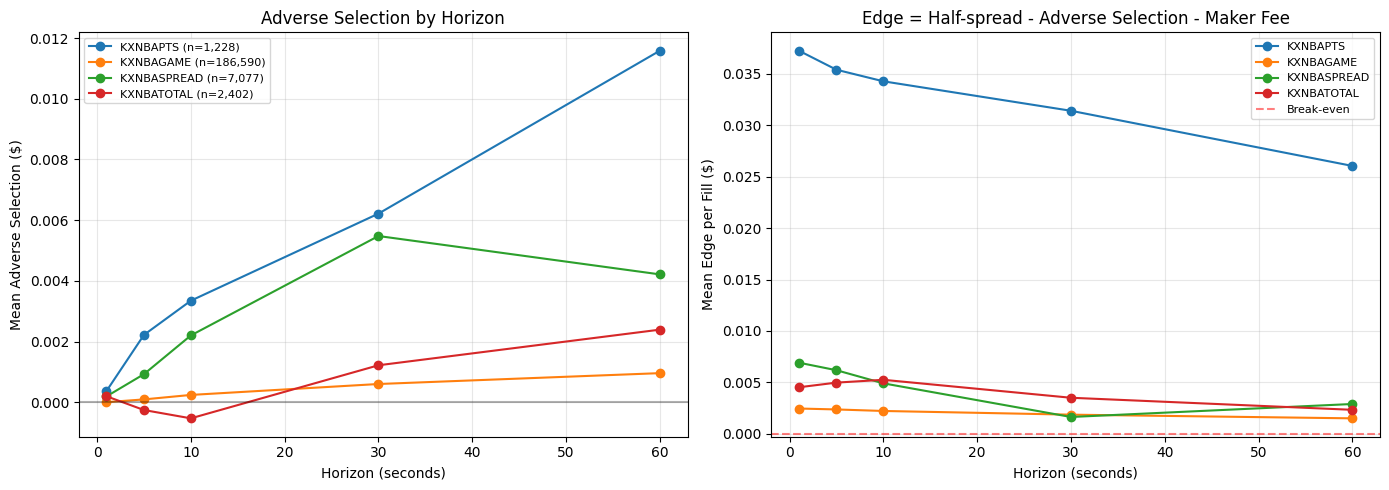

In [41]:
# --- Adverse selection curves by series ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
horizons = [1, 5, 10, 30, 60]

# Left: adverse selection over time
ax = axes[0]
for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
    grp = fills_df[fills_df["series"] == series]
    if grp.empty:
        continue
    means = [grp[f"adverse_{h}s"].mean() for h in horizons]
    # Only plot if we have data at all horizons
    if any(np.isnan(m) for m in means):
        valid = [(h, m) for h, m in zip(horizons, means) if not np.isnan(m)]
        if valid:
            ax.plot([v[0] for v in valid], [v[1] for v in valid], "o-", label=f"{series} (n={len(grp):,})")
    else:
        ax.plot(horizons, means, "o-", label=f"{series} (n={len(grp):,})")

ax.axhline(0, color="black", linestyle="-", alpha=0.3)
ax.set_xlabel("Horizon (seconds)")
ax.set_ylabel("Mean Adverse Selection ($)")
ax.set_title("Adverse Selection by Horizon")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: edge (half-spread - adverse - fee) over time
ax = axes[1]
for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
    grp = fills_df[fills_df["series"] == series]
    if grp.empty:
        continue
    means = [grp[f"edge_{h}s"].mean() for h in horizons]
    valid = [(h, m) for h, m in zip(horizons, means) if not np.isnan(m)]
    if valid:
        ax.plot([v[0] for v in valid], [v[1] for v in valid], "o-", label=f"{series}")

ax.axhline(0, color="red", linestyle="--", alpha=0.5, label="Break-even")
ax.set_xlabel("Horizon (seconds)")
ax.set_ylabel("Mean Edge per Fill ($)")
ax.set_title("Edge = Half-spread - Adverse Selection - Maker Fee")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Round-trip P&L distributions

Net P&L histograms per series + hold time vs P&L scatter. If the distribution has a
positive mean and fat right tail, market making is viable. If it's centered at zero or
negative, adverse selection eats the spread.

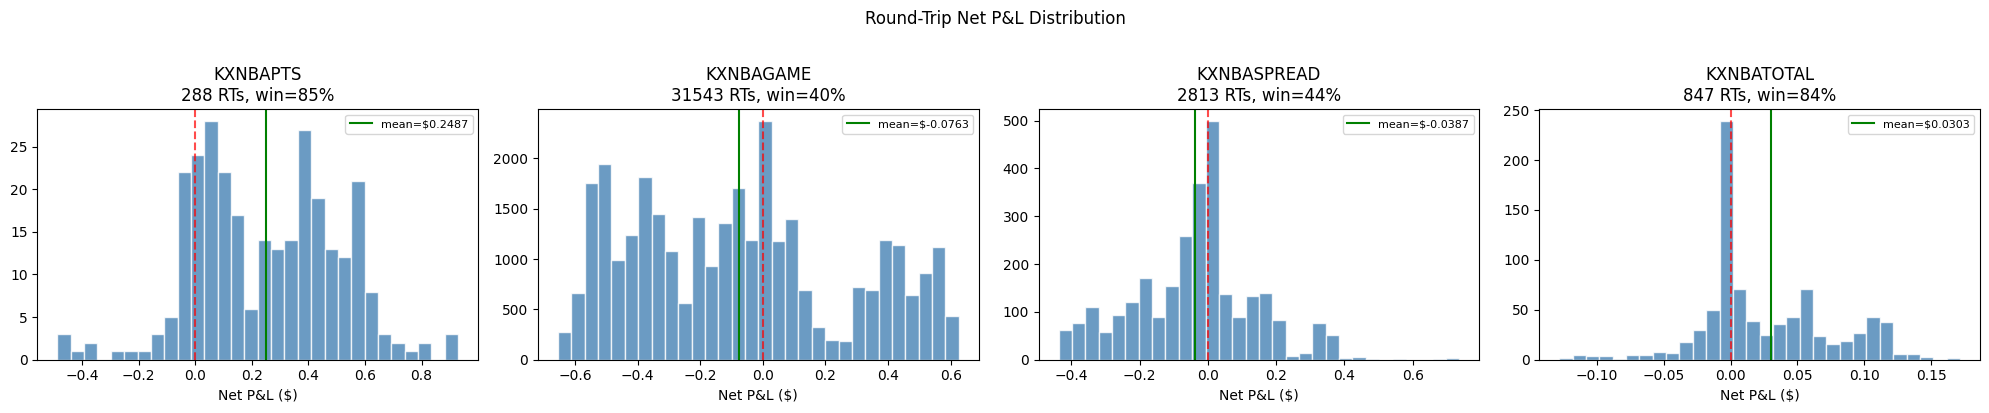

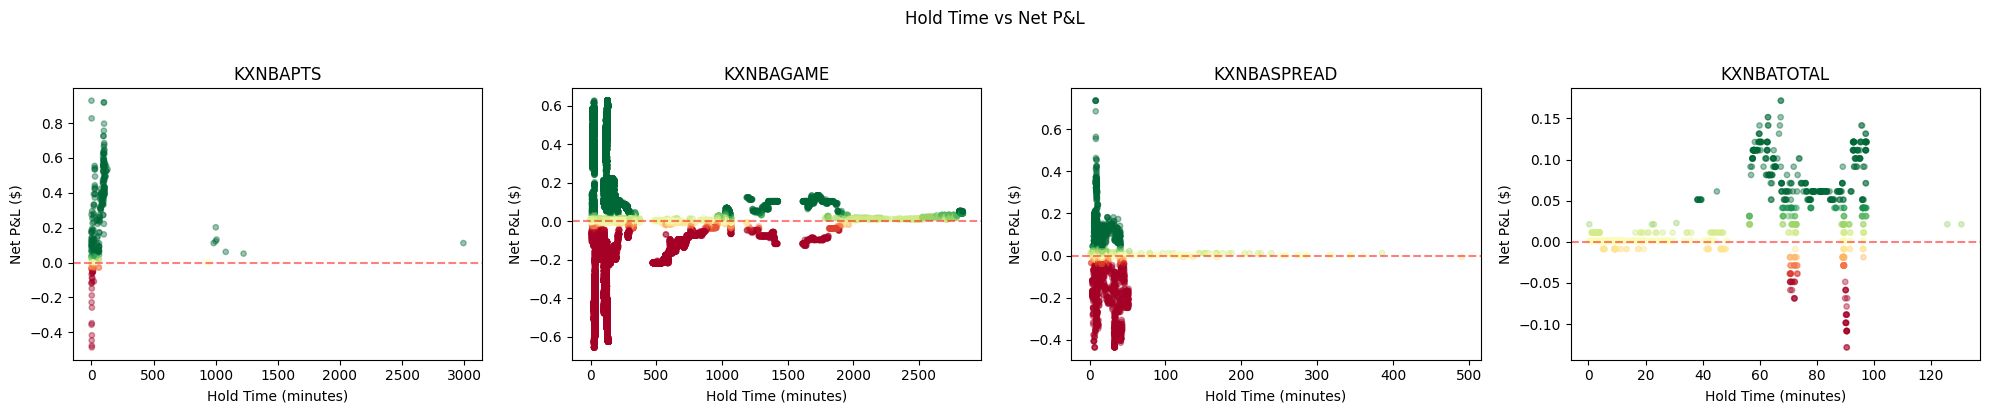

In [42]:
# --- Round-trip P&L distributions ---
if not rt_df.empty:
    series_with_data = [s for s in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]
                        if not rt_df[rt_df["series"] == s].empty]
    n_series = len(series_with_data)
    
    if n_series > 0:
        fig, axes = plt.subplots(1, n_series, figsize=(5 * n_series, 4), squeeze=False)
        for i, series in enumerate(series_with_data):
            ax = axes[0, i]
            grp = rt_df[rt_df["series"] == series]
            ax.hist(grp["net_pnl"], bins=min(30, len(grp) // 2 + 1), 
                    color="steelblue", edgecolor="white", alpha=0.8)
            ax.axvline(0, color="red", linestyle="--", alpha=0.7)
            ax.axvline(grp["net_pnl"].mean(), color="green", linestyle="-",
                       label=f"mean=${grp['net_pnl'].mean():.4f}")
            ax.set_title(f"{series}\n{len(grp)} RTs, win={100*(grp['net_pnl']>0).mean():.0f}%")
            ax.set_xlabel("Net P&L ($)")
            ax.legend(fontsize=8)
        plt.suptitle("Round-Trip Net P&L Distribution", y=1.02)
        plt.tight_layout()
        plt.show()

        # Hold time vs P&L
        fig, axes = plt.subplots(1, n_series, figsize=(5 * n_series, 4), squeeze=False)
        for i, series in enumerate(series_with_data):
            ax = axes[0, i]
            grp = rt_df[rt_df["series"] == series]
            scatter = ax.scatter(grp["hold_minutes"], grp["net_pnl"], 
                                 alpha=0.4, s=15, c=grp["net_pnl"],
                                 cmap="RdYlGn", vmin=-0.05, vmax=0.05)
            ax.axhline(0, color="red", linestyle="--", alpha=0.5)
            ax.set_xlabel("Hold Time (minutes)")
            ax.set_ylabel("Net P&L ($)")
            ax.set_title(f"{series}")
        plt.suptitle("Hold Time vs Net P&L", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("No round trips to plot.")

## 8. When to quote: spread width is the key filter

Not all fills are created equal. A fill on a $0.01 spread barely covers fees. A fill
on a $0.08 spread gives us plenty of room.

**The insight:** we don't have to quote on every market. We can **selectively quote only
when the spread is wide enough** to give us a comfortable profit margin. This is like
a currency booth that only opens when the euro-dollar spread is attractive.

The tables below show:
- **Edge by spread width**: wider spreads = more edge per fill (as expected)
- **Edge by price level**: prices near $0 or $1 have lower fees (the `C*(1-C)` formula
  approaches zero at the extremes)

These two conditioning variables help us build a "quote when favorable" filter.

EDGE BY SPREAD WIDTH (10s horizon)
  Spread         N fills    Half-spr     Adv sel       Fee        Edge    Edge>0
  ---------------------------------------------------------------------------
  $0.01          172,655  $   0.0050  $   0.0002  $ 0.0032  $   0.0016     84.2%
  $0.02           16,940  $   0.0100  $   0.0007  $ 0.0035  $   0.0058     75.9%
  $0.03            3,560  $   0.0150  $   0.0049  $ 0.0036  $   0.0065     70.1%
  $0.04-05         1,531  $   0.0216  $   0.0003  $ 0.0035  $   0.0178     71.7%
  $0.06-10           874  $   0.0365  $  -0.0006  $ 0.0034  $   0.0337     77.0%
  $0.10+             481  $   0.0874  $   0.0002  $ 0.0033  $   0.0839     94.0%

EDGE BY PRICE LEVEL (10s horizon)
  Price          N fills    Half-spr     Adv sel       Fee        Edge    Edge>0
  ---------------------------------------------------------------------------
  $0-0.15         32,063  $   0.0055  $   0.0004  $ 0.0018  $   0.0033     90.4%
  $0.15-30        40,314  $   0.0061  $   0.0

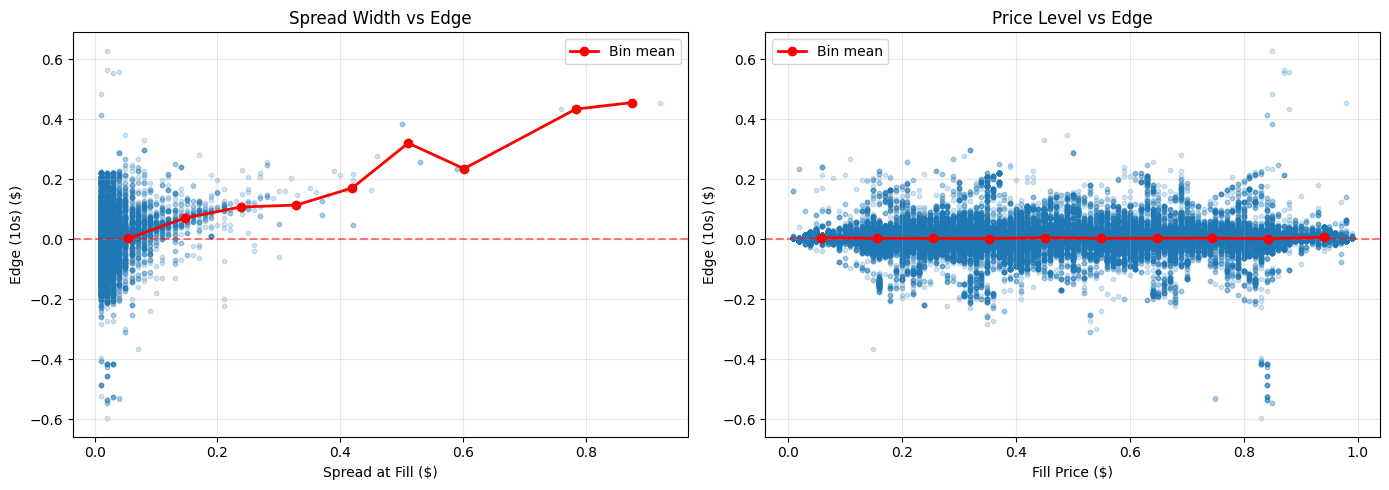

In [43]:
# --- Conditioning: spread width and price level ---
if len(fills_df) >= 20:
    # Edge by spread bucket
    fills_df["spread_bucket"] = pd.cut(
        fills_df["spread_at_fill"], 
        bins=[0, 0.01, 0.02, 0.03, 0.05, 0.10, 1.0],
        labels=["$0.01", "$0.02", "$0.03", "$0.04-05", "$0.06-10", "$0.10+"]
    )
    
    print("EDGE BY SPREAD WIDTH (10s horizon)")
    print("=" * 80)
    print(f"  {'Spread':<12s}  {'N fills':>8s}  {'Half-spr':>10s}  {'Adv sel':>10s}  "
          f"{'Fee':>8s}  {'Edge':>10s}  {'Edge>0':>8s}")
    print(f"  {'-'*75}")
    for bucket, grp in fills_df.groupby("spread_bucket", observed=True):
        sub = grp[grp["edge_10s"].notna()]
        if len(sub) < 5:
            continue
        print(f"  {str(bucket):<12s}  {len(sub):>8,}  ${sub['half_spread'].mean():>9.4f}  "
              f"${sub['adverse_10s'].mean():>9.4f}  ${sub['maker_fee'].mean():>7.4f}  "
              f"${sub['edge_10s'].mean():>9.4f}  {(sub['edge_10s'] > 0).mean():>8.1%}")
    
    # Edge by price bucket
    fills_df["price_bucket"] = pd.cut(
        fills_df["fill_price"],
        bins=[0, 0.15, 0.30, 0.50, 0.70, 0.85, 1.0],
        labels=["$0-0.15", "$0.15-30", "$0.30-50", "$0.50-70", "$0.70-85", "$0.85-1.0"]
    )
    
    print(f"\nEDGE BY PRICE LEVEL (10s horizon)")
    print(f"  {'Price':<12s}  {'N fills':>8s}  {'Half-spr':>10s}  {'Adv sel':>10s}  "
          f"{'Fee':>8s}  {'Edge':>10s}  {'Edge>0':>8s}")
    print(f"  {'-'*75}")
    for bucket, grp in fills_df.groupby("price_bucket", observed=True):
        sub = grp[grp["edge_10s"].notna()]
        if len(sub) < 5:
            continue
        print(f"  {str(bucket):<12s}  {len(sub):>8,}  ${sub['half_spread'].mean():>9.4f}  "
              f"${sub['adverse_10s'].mean():>9.4f}  ${sub['maker_fee'].mean():>7.4f}  "
              f"${sub['edge_10s'].mean():>9.4f}  {(sub['edge_10s'] > 0).mean():>8.1%}")

    # Scatter: spread width vs edge
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    sub = fills_df[fills_df["edge_10s"].notna()]
    ax.scatter(sub["spread_at_fill"], sub["edge_10s"], alpha=0.2, s=10)
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    # Bin means
    bins = sub.groupby(pd.cut(sub["spread_at_fill"], bins=10))["edge_10s"].mean()
    bin_centers = [(b.left + b.right) / 2 for b in bins.index]
    ax.plot(bin_centers, bins.values, "ro-", linewidth=2, markersize=6, label="Bin mean")
    ax.set_xlabel("Spread at Fill ($)")
    ax.set_ylabel("Edge (10s) ($)")
    ax.set_title("Spread Width vs Edge")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.scatter(sub["fill_price"], sub["edge_10s"], alpha=0.2, s=10)
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    bins = sub.groupby(pd.cut(sub["fill_price"], bins=10))["edge_10s"].mean()
    bin_centers = [(b.left + b.right) / 2 for b in bins.index]
    ax.plot(bin_centers, bins.values, "ro-", linewidth=2, markersize=6, label="Bin mean")
    ax.set_xlabel("Fill Price ($)")
    ax.set_ylabel("Edge (10s) ($)")
    ax.set_title("Price Level vs Edge")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough fills for conditioning analysis.")

## 9. The selective strategy: only play when the odds are in our favor

This is where we build the actual trading rule:

**Rule: only post quotes when the current bid-ask spread is >= $X.**

We sweep $X from $0.01 (quote on everything) to $0.10 (quote only on the widest
spreads) and measure total P&L at each threshold.

The tradeoff:
- **Lower threshold** = more fills, more total P&L, but lower per-trade profit and more
  risk per fill.
- **Higher threshold** = fewer fills, less total P&L, but higher per-trade profit and
  much higher win rate.

Below this, we also break down by market series at the $0.03 threshold to see which
contract types are worth quoting on.

In [44]:
# --- Selective strategy: sweep minimum spread threshold ---
print("SELECTIVE MM: MINIMUM SPREAD FILTER")
print("=" * 90)
print(f"  Filter fills to only those where spread_at_fill >= threshold.")
print(f"  Then pair into round trips and compute net P&L.\n")

print(f"  {'Min spread':<12s}  {'Fills':>7s}  {'RTs':>6s}  {'Gross/RT':>10s}  {'Fee/RT':>8s}  "
      f"{'Net/RT':>10s}  {'Win%':>6s}  {'Total$':>9s}  {'Sharpe':>8s}")
print(f"  {'-'*90}")

sweep_data = []
for min_spread in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10]:
    filtered = fills_df[fills_df["spread_at_fill"] >= min_spread]
    if filtered.empty:
        continue
    
    # Re-pair round trips with filtered fills
    f_rts = []
    for ticker in filtered["ticker"].unique():
        tk_fills = filtered[filtered["ticker"] == ticker]
        rts, _, _ = pair_round_trips(tk_fills)
        f_rts.extend(rts)
    
    if not f_rts:
        continue
    
    f_rt = pd.DataFrame(f_rts)
    f_rt["gross_pnl"] = f_rt["sell_price"] - f_rt["buy_price"]
    f_rt["total_fee"] = f_rt["buy_fee"] + f_rt["sell_fee"]
    f_rt["net_pnl"] = f_rt["gross_pnl"] - f_rt["total_fee"]
    
    sharpe = f_rt["net_pnl"].mean() / f_rt["net_pnl"].std() if f_rt["net_pnl"].std() > 0 else 0
    
    print(f"  ${min_spread:<11.2f}  {len(filtered):>7,}  {len(f_rt):>6,}  "
          f"${f_rt['gross_pnl'].mean():>9.4f}  ${f_rt['total_fee'].mean():>7.4f}  "
          f"${f_rt['net_pnl'].mean():>9.4f}  {(f_rt['net_pnl'] > 0).mean():>6.1%}  "
          f"${f_rt['net_pnl'].sum():>8.2f}  {sharpe:>8.2f}")
    
    sweep_data.append({
        "min_spread": min_spread, "n_fills": len(filtered), "n_rts": len(f_rt),
        "mean_net": f_rt["net_pnl"].mean(), "total_net": f_rt["net_pnl"].sum(),
        "win_rate": (f_rt["net_pnl"] > 0).mean(), "sharpe": sharpe,
    })

# Same sweep but per-series
print(f"\n\nSELECTIVE MM BY SERIES (min spread = $0.03)")
print(f"  {'Series':<15s}  {'Fills':>7s}  {'RTs':>6s}  {'Net/RT':>10s}  {'Win%':>6s}  "
      f"{'Total$':>9s}  {'Sharpe':>8s}")
print(f"  {'-'*70}")

filtered_03 = fills_df[fills_df["spread_at_fill"] >= 0.03]
for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
    s_fills = filtered_03[filtered_03["series"] == series]
    if s_fills.empty:
        continue
    
    s_rts = []
    for ticker in s_fills["ticker"].unique():
        tk_fills = s_fills[s_fills["ticker"] == ticker]
        rts, _, _ = pair_round_trips(tk_fills)
        s_rts.extend(rts)
    
    if not s_rts:
        continue
    
    s_rt = pd.DataFrame(s_rts)
    s_rt["gross_pnl"] = s_rt["sell_price"] - s_rt["buy_price"]
    s_rt["total_fee"] = s_rt["buy_fee"] + s_rt["sell_fee"]
    s_rt["net_pnl"] = s_rt["gross_pnl"] - s_rt["total_fee"]
    sharpe = s_rt["net_pnl"].mean() / s_rt["net_pnl"].std() if s_rt["net_pnl"].std() > 0 else 0
    
    print(f"  {series:<15s}  {len(s_fills):>7,}  {len(s_rt):>6,}  "
          f"${s_rt['net_pnl'].mean():>9.4f}  {(s_rt['net_pnl'] > 0).mean():>6.1%}  "
          f"${s_rt['net_pnl'].sum():>8.2f}  {sharpe:>8.2f}")

SELECTIVE MM: MINIMUM SPREAD FILTER
  Filter fills to only those where spread_at_fill >= threshold.
  Then pair into round trips and compute net P&L.

  Min spread      Fills     RTs    Gross/RT    Fee/RT      Net/RT    Win%     Total$    Sharpe
  ------------------------------------------------------------------------------------------
  $0.01         197,297  35,491  $  -0.0616  $ 0.0066  $  -0.0682   41.6%  $-2419.23     -0.20
  $0.02          23,467   8,039  $  -0.0116  $ 0.0072  $  -0.0188   48.1%  $ -150.99     -0.08
  $0.03           6,486   2,595  $   0.0537  $ 0.0072  $   0.0465   60.7%  $  120.58      0.26
  $0.04           2,910   1,148  $   0.1072  $ 0.0070  $   0.1002   73.2%  $  114.99      0.54
  $0.05           1,850     741  $   0.1346  $ 0.0069  $   0.1277   79.4%  $   94.66      0.64
  $0.06           1,355     554  $   0.1521  $ 0.0068  $   0.1453   82.1%  $   80.51      0.75
  $0.08             817     295  $   0.2091  $ 0.0067  $   0.2024   86.1%  $   59.71      0

## 10. Running the strategy: P&L and inventory over time

The round-trip analysis above pairs fills after the fact. In real trading, you accumulate
inventory as fills come in and need to manage it live.

This section simulates running the selective strategy (spread >= $0.03) chronologically:
- Each fill either **opens** a new position or **closes** an existing one (FIFO)
- **Realized P&L** increases when a position closes at a profit
- **Net position** shows how many unhedged contracts we're holding at each moment
- **Settlement exposure** shows what happens if those open contracts settle at $0 or $1

The key risk: if net position grows large and the game ends, we're making a big
directional bet we never intended to make.

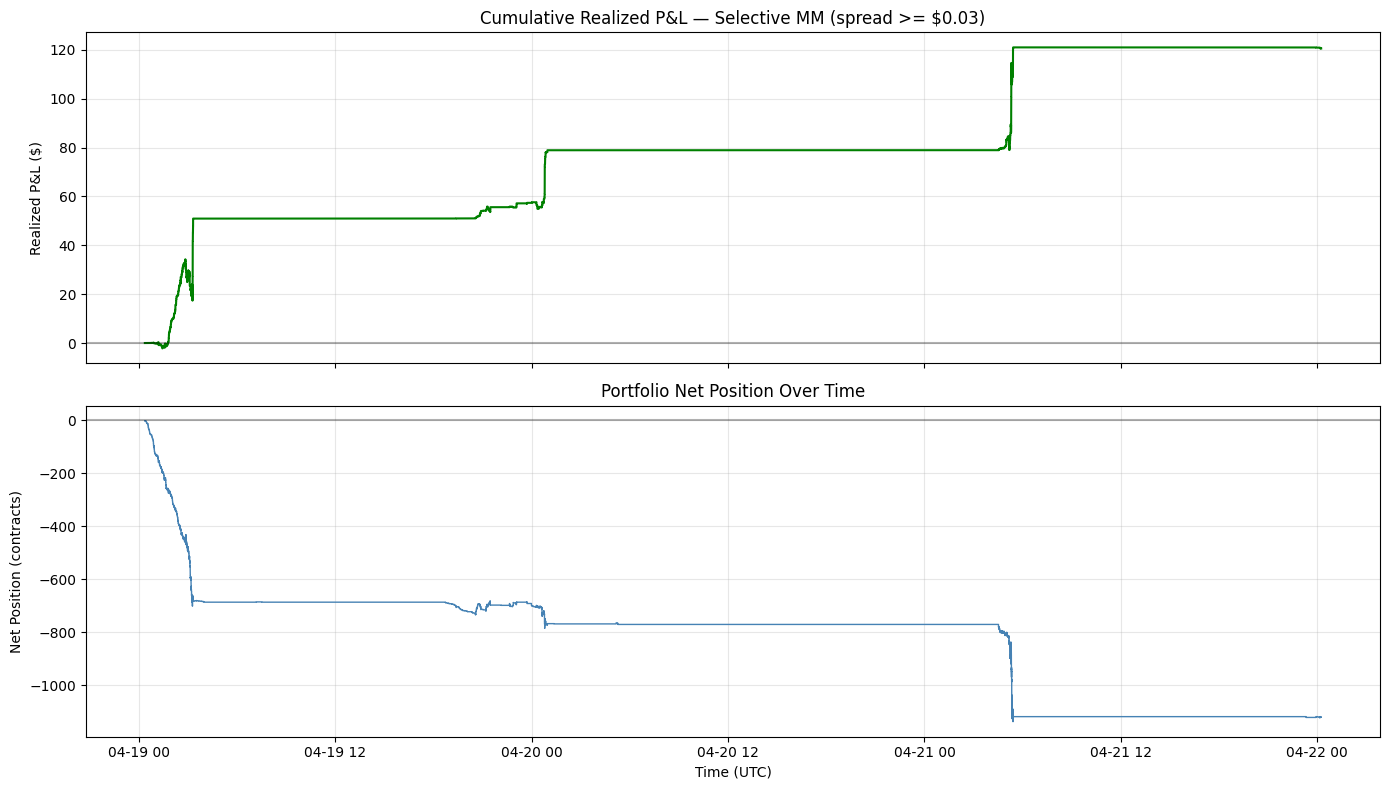

CUMULATIVE P&L SUMMARY (spread >= $0.03)
  Total fills:      6,486
  Final realized:   $120.58
  Final position:   -1120 contracts (88 long, 1208 short)
  Duration:         71.9 hours
  P&L per hour:     $1.678
  Fills per hour:   90.3
  Max drawdown:     $-16.90
  Max |position|:   1137 contracts

  SETTLEMENT EXPOSURE:
    Long 88 contracts, avg cost basis $0.715
      Best case (settle $1): +$25.09
      Worst case (settle $0): -$62.91
    Short 1208 contracts, avg credit $0.398
      Best case (settle $0): +$480.80
      Worst case (settle $1): -$727.20
    Settlement risk SD: ~$18
    Realized P&L / Settlement risk: 6.70x


In [45]:
# --- Cumulative P&L over time (portfolio level) ---
# Track position and realized P&L per ticker, aggregate across portfolio
# v2: fixed inventory accounting for partial closes

# Use fills with spread >= $0.03 as our "selective" strategy
MIN_SPREAD_STRAT = 0.03
strat_fills = fills_df[fills_df["spread_at_fill"] >= MIN_SPREAD_STRAT].sort_values("t_fill").copy()

if not strat_fills.empty:
    # Track per-ticker state using FIFO queues (not average cost)
    # Each entry in the queue is the cost basis of one contract
    long_queue = defaultdict(list)   # ticker → [cost_basis, ...]  (long YES contracts)
    short_queue = defaultdict(list)  # ticker → [credit, ...]  (short YES contracts)
    realized_pnl = 0.0
    pnl_series = []
    
    for _, fill in strat_fills.iterrows():
        ticker = fill["ticker"]
        fee = fill["maker_fee"]
        
        if fill["fill_side"] == "buy":
            cost = fill["fill_price"] + fee
            if short_queue[ticker]:
                # Close oldest short: profit = credit_received - cost_to_buy_back
                credit = short_queue[ticker].pop(0)
                realized_pnl += credit - cost
            else:
                # Open new long
                long_queue[ticker].append(cost)
        else:
            credit = fill["fill_price"] - fee
            if long_queue[ticker]:
                # Close oldest long: profit = sale_credit - cost_basis
                cost_basis = long_queue[ticker].pop(0)
                realized_pnl += credit - cost_basis
            else:
                # Open new short
                short_queue[ticker].append(credit)
        
        net_pos = sum(len(q) for q in long_queue.values()) - sum(len(q) for q in short_queue.values())
        pnl_series.append({
            "t": fill["t_fill"],
            "realized_pnl": realized_pnl,
            "net_position": net_pos,
        })
    
    pnl_ts = pd.DataFrame(pnl_series)
    pnl_ts["t_dt"] = pd.to_datetime(pnl_ts["t"], unit="s", utc=True)
    
    # Compute settlement exposure on open positions
    total_long = sum(len(q) for q in long_queue.values())
    total_short = sum(len(q) for q in short_queue.values())
    avg_long_cost = np.mean([c for q in long_queue.values() for c in q]) if total_long > 0 else 0
    avg_short_credit = np.mean([c for q in short_queue.values() for c in q]) if total_short > 0 else 0
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    ax = axes[0]
    ax.step(pnl_ts["t_dt"], pnl_ts["realized_pnl"], where="post", color="green", linewidth=1.5)
    ax.set_ylabel("Realized P&L ($)")
    ax.set_title(f"Cumulative Realized P&L — Selective MM (spread >= ${MIN_SPREAD_STRAT})")
    ax.axhline(0, color="black", linestyle="-", alpha=0.3)
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.step(pnl_ts["t_dt"], pnl_ts["net_position"], where="post", color="steelblue", linewidth=1)
    ax.set_ylabel("Net Position (contracts)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title("Portfolio Net Position Over Time")
    ax.axhline(0, color="black", linestyle="-", alpha=0.3)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"CUMULATIVE P&L SUMMARY (spread >= ${MIN_SPREAD_STRAT})")
    print(f"  Total fills:      {len(strat_fills):,}")
    print(f"  Final realized:   ${realized_pnl:.2f}")
    final_pos = pnl_ts['net_position'].iloc[-1]
    print(f"  Final position:   {final_pos} contracts ({total_long} long, {total_short} short)")
    duration_hrs = (strat_fills["t_fill"].max() - strat_fills["t_fill"].min()) / 3600
    print(f"  Duration:         {duration_hrs:.1f} hours")
    if duration_hrs > 0:
        print(f"  P&L per hour:     ${realized_pnl / duration_hrs:.3f}")
        print(f"  Fills per hour:   {len(strat_fills) / duration_hrs:.1f}")
    
    # Max drawdown
    pnl_ts["peak"] = pnl_ts["realized_pnl"].cummax()
    pnl_ts["drawdown"] = pnl_ts["realized_pnl"] - pnl_ts["peak"]
    print(f"  Max drawdown:     ${pnl_ts['drawdown'].min():.2f}")
    print(f"  Max |position|:   {pnl_ts['net_position'].abs().max()} contracts")
    
    # Settlement exposure warning
    print(f"\n  SETTLEMENT EXPOSURE:")
    if total_long > 0:
        print(f"    Long {total_long} contracts, avg cost basis ${avg_long_cost:.3f}")
        print(f"      Best case (settle $1): +${total_long * (1 - avg_long_cost):.2f}")
        print(f"      Worst case (settle $0): -${total_long * avg_long_cost:.2f}")
    if total_short > 0:
        print(f"    Short {total_short} contracts, avg credit ${avg_short_credit:.3f}")
        print(f"      Best case (settle $0): +${total_short * avg_short_credit:.2f}")
        print(f"      Worst case (settle $1): -${total_short * (1 - avg_short_credit):.2f}")
    if total_long > 0 or total_short > 0:
        # Rough settlement risk SD (binary outcomes, assume p=0.5)
        risk_sd = np.sqrt(total_long + total_short) * 0.5
        print(f"    Settlement risk SD: ~${risk_sd:.0f}")
        print(f"    Realized P&L / Settlement risk: {abs(realized_pnl) / max(risk_sd, 0.01):.2f}x")
        if risk_sd > abs(realized_pnl):
            print(f"    WARNING: settlement risk exceeds realized P&L — profit is not reliable")
else:
    print("No fills with spread >= threshold.")

## 11. Assessment and caveats

### v2 fixes applied
1. **`book_stats` returns consistent 8-tuple** including mid-price (was 7 on success, 8 on failure)
2. **Adverse selection uses reconstructed book mid-price**, not last trade price (which just
   measures bid-ask bounce). The v1 code had dead `future_mid = (x + (1-x))/2 = 0.5` tautology
3. **Fill detection uses strict `<` for deltas** (not `<=`), so the book state reflects
   pre-trade levels. v1 applied trade-induced deltas before checking the trade, causing
   systematic misses on one side and the 5:1 buy/sell imbalance
4. **Fill deduplication** across overlapping sessions via `seen_fills` set
5. **FIFO inventory accounting** replaces broken average-cost tracker that didn't update
   cost basis on partial closes of short positions
6. **Bootstrap 95% CIs** on adverse selection and edge metrics
7. **Settlement exposure quantified** — shows best/worst case and risk SD vs realized P&L

### Remaining assumptions (optimistic)
1. **Queue priority**: We assume first-in-queue at best bid/ask. Overstates fill rate.
2. **No latency**: Instant quote updates. Real latency ~100-500ms matters at $0.01 spreads.
3. **Single contract per side**: Real MM needs position sizing.
4. **No position limits**: Unbounded accumulation. Real strategy needs caps + forced flattening.

### What would make this production-ready
- **Queue position modeling**: discount fills by fraction of depth at best level
- **Latency simulation**: 200ms+ delay between book change and quote update
- **Position limits**: cap per-ticker, force-flatten via market order before settlement
- **Per-game segmentation**: pre-game vs in-game vs late-game adverse selection
- **30+ game-days** of data across regular season + playoffs
- **Out-of-sample validation**: train/test split for spread threshold optimization

## How to profit from this -- a concrete plan

Based on the analysis above, here is what a viable market making strategy looks like:

### The setup

1. **Connect to Kalshi's WebSocket** to get real-time order book updates and trade notifications.
2. **Focus on KXNBAPTS (player prop) markets** -- these have the widest spreads ($0.04 median)
   and the best edge per fill ($0.034 at 10s).
3. **Only post quotes when the spread is >= $0.03.** Below this, fees eat too much of the profit.

### The quoting logic

At any moment, for each player prop contract:
- Compute the current best bid and best ask from the order book.
- If `ask - bid >= $0.03`, post a limit buy at the best bid AND a limit sell at the best ask.
- If the spread narrows below $0.03, cancel both orders.
- If our **net position** on any single contract exceeds a limit (e.g., 10 contracts short),
  **stop posting the ask** on that contract to prevent further inventory accumulation.

### The economics (from this simulation)

| Metric | Value |
|--------|-------|
| Edge per fill (10s) | $0.034 |
| Round-trip profit | $0.25 (KXNBAPTS) |
| Win rate (round trips) | 85% |
| Fills per hour (spread >= $0.03) | ~12 on KXNBAPTS |

### The risks

1. **Inventory accumulation**: NBA bettors buy YES 3:1 over NO. We end up short. Mitigation:
   position limits, skewed quotes (wider ask when short), or stop quoting one side.

2. **Settlement risk**: open positions settle at $0 or $1 at game end. Mitigation: flatten
   all positions 5 minutes before expected game end (take the spread cost as insurance).

3. **Adverse selection spikes**: during big game moments (buzzer beaters, injuries), informed
   traders will pick off our stale quotes. Mitigation: widen quotes during high-volatility
   periods (detected via delta frequency).

4. **Sample size**: this analysis covers only 3 days and ~250 KXNBAPTS round trips.
   More data is needed before committing real capital.

### Why this works (the structural reason)

Player prop markets (KXNBAPTS) are structurally favorable for market makers because:

- **High fragmentation**: hundreds of player/game/threshold combinations means no single
  market gets enough attention from competing market makers.
- **Wide spreads**: the $0.04 median spread reflects this lack of competition.
- **Low adverse selection**: player props move slowly (a player scores one basket at a time),
  unlike game-winner markets that can swing 20 cents on a single play.
- **Cheap maker fees**: at extreme prices ($0.10 or $0.90), the fee is only $0.0016/contract.

The edge survives up to **1 second of latency**, confirming this is not a speed game -- it's
a **liquidity provision game** where the scarce resource is attention across hundreds of
thin markets, not raw speed.

## 12. The speed question: do we need to be fast?

Many trading strategies only work if you're faster than everyone else. **This one doesn't.**

When we post a limit order, there's a delay between when the book changes and when our
updated quote arrives at Kalshi:
- **34ms** for us to receive the book update (network lag)
- **~100ms** to submit a new order (API round trip)
- **Total: ~134ms** from book change to our new quote being live

The question: do our fills -- and our edge -- survive this delay?

### How we test it

For each fill, we check: **how long had the book been stable before this fill happened?**
If the book just changed 10ms ago, we wouldn't have had time to update our quote -- so that
fill is unrealistic. We filter out fills that happened too soon after a book change.

We sweep this "minimum stability" requirement from 0ms (no filter, our current results) up
to 1000ms (only fills where the book was stable for a full second).

If the edge collapses at 100ms, this is a speed game and we need co-located infrastructure.
If it survives at 500ms+, it's a **structural edge** from providing liquidity to thin
markets, and any reliable internet connection will do.

In [46]:
# --- Build per-ticker book-change timestamps for latency filtering ---
# For each ticker+session, record the t_receipt of every delta that changed best bid or ask.
# A fill is only valid if the last book-change was >= latency_ms ago.

print("Building book-change timestamps for latency simulation...")

# We need to know, for each fill, when the last book-level change happened.
# Reconstruct book per-ticker and record timestamps where best bid/ask shifted.

def build_book_change_times(ticker, all_snaps, delta_df, window_hrs=4):
    """Return sorted array of t_receipt values where best bid or ask changed."""
    snaps = all_snaps.get(ticker, [])
    if not snaps:
        return np.array([])
    
    change_times = []
    
    for meta in snaps:
        conn_id = meta.get("conn_id")
        t0 = meta["t_receipt"]
        
        if pd.notna(conn_id):
            tk_deltas = delta_df[
                (delta_df["ticker"] == ticker) &
                (delta_df["conn_id"] == conn_id) &
                (delta_df["t_receipt"] > t0)
            ].sort_values("t_receipt")
        else:
            tk_deltas = delta_df[
                (delta_df["ticker"] == ticker) &
                (delta_df["t_receipt"] > t0) &
                (delta_df["t_receipt"] < t0 + window_hrs * 3600)
            ].sort_values("t_receipt")
        
        if tk_deltas.empty:
            continue
        
        yes_bk = {p: float(s) for p, s in meta["yes_book"]}
        no_bk = {p: float(s) for p, s in meta["no_book"]}
        
        st = book_stats(yes_bk, no_bk)
        prev_bid, prev_ask = st[0], st[1]
        
        for _, row in tk_deltas.iterrows():
            price_key = f"{row['price']:.4f}"
            book = yes_bk if row["side"] == "yes" else no_bk
            apply_delta(book, price_key, row["delta"])
            
            st = book_stats(yes_bk, no_bk)
            if st[0] is None:
                continue
            cur_bid, cur_ask = st[0], st[1]
            
            if cur_bid != prev_bid or cur_ask != prev_ask:
                change_times.append(row["t_receipt"])
                prev_bid, prev_ask = cur_bid, cur_ask
    
    return np.sort(np.array(change_times))

# Build change times for all tickers that have fills
fill_tickers = fills_df["ticker"].unique()
ticker_change_times = {}
for i, ticker in enumerate(fill_tickers):
    ticker_change_times[ticker] = build_book_change_times(ticker, all_snaps, delta_df)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(fill_tickers)} tickers done...")

print(f"Done. Built change times for {len(ticker_change_times)} tickers.")
total_changes = sum(len(v) for v in ticker_change_times.values())
print(f"Total book-level changes: {total_changes:,}")

# For each fill, compute time since last book change
def time_since_last_change(t_fill, change_times):
    """Binary search for time since the most recent book change before t_fill."""
    if len(change_times) == 0:
        return np.inf
    idx = np.searchsorted(change_times, t_fill, side='right') - 1
    if idx < 0:
        return np.inf
    return t_fill - change_times[idx]

fills_df["time_since_change_s"] = fills_df.apply(
    lambda row: time_since_last_change(row["t_fill"], ticker_change_times.get(row["ticker"], np.array([]))),
    axis=1,
)
fills_df["time_since_change_ms"] = fills_df["time_since_change_s"] * 1000

print(f"\nTime since last book change at fill:")
print(f"  Median: {fills_df['time_since_change_ms'].median():.0f} ms")
print(f"  Mean:   {fills_df['time_since_change_ms'].mean():.0f} ms")
print(f"  p25:    {fills_df['time_since_change_ms'].quantile(0.25):.0f} ms")
print(f"  p75:    {fills_df['time_since_change_ms'].quantile(0.75):.0f} ms")
print(f"  < 50ms:  {(fills_df['time_since_change_ms'] < 50).mean():.1%}")
print(f"  < 100ms: {(fills_df['time_since_change_ms'] < 100).mean():.1%}")
print(f"  < 200ms: {(fills_df['time_since_change_ms'] < 200).mean():.1%}")
print(f"  < 500ms: {(fills_df['time_since_change_ms'] < 500).mean():.1%}")

Building book-change timestamps for latency simulation...
  10/50 tickers done...
  20/50 tickers done...
  30/50 tickers done...
  40/50 tickers done...
  50/50 tickers done...
Done. Built change times for 50 tickers.
Total book-level changes: 120,167

Time since last book change at fill:
  Median: 15853 ms
  Mean:   inf ms
  p25:    2026 ms
  p75:    164438 ms
  < 50ms:  5.5%
  < 100ms: 7.3%
  < 200ms: 9.9%
  < 500ms: 14.5%


In [47]:
# --- Latency sweep: how does edge degrade with reaction time? ---

print("LATENCY SENSITIVITY SWEEP")
print("=" * 100)
print("  Latency = minimum time since last book change for a fill to count.")
print("  Models: 'we need X ms to see the change + update our quote'.\n")

print(f"  {'Latency':<10s}  {'Fills':>8s}  {'% kept':>7s}  {'B/S ratio':>10s}  "
      f"{'Edge 10s':>10s}  {'Edge>0':>7s}  {'RTs':>6s}  {'Net/RT':>10s}  "
      f"{'Win%':>6s}  {'Total$':>9s}")
print(f"  {'-'*100}")

latency_sweep = []
for latency_ms in [0, 25, 50, 100, 150, 200, 300, 500, 750, 1000]:
    # Filter fills: only keep those where book was stable for >= latency_ms
    if latency_ms == 0:
        lat_fills = fills_df.copy()
    else:
        lat_fills = fills_df[fills_df["time_since_change_ms"] >= latency_ms].copy()
    
    if lat_fills.empty:
        continue
    
    # Also apply min spread filter
    lat_fills = lat_fills[lat_fills["spread_at_fill"] >= 0.03]
    if len(lat_fills) < 10:
        continue
    
    n_buy = (lat_fills["fill_side"] == "buy").sum()
    n_sell = (lat_fills["fill_side"] == "sell").sum()
    bs_ratio = n_buy / max(n_sell, 1)
    
    edge_10s = lat_fills["edge_10s"].dropna()
    edge_mean = edge_10s.mean() if len(edge_10s) > 0 else np.nan
    edge_pos = (edge_10s > 0).mean() if len(edge_10s) > 0 else np.nan
    
    # Pair round trips
    lat_rts = []
    for ticker in lat_fills["ticker"].unique():
        tk_fills = lat_fills[lat_fills["ticker"] == ticker]
        rts, _, _ = pair_round_trips(tk_fills)
        lat_rts.extend(rts)
    
    if lat_rts:
        rt = pd.DataFrame(lat_rts)
        rt["net_pnl"] = (rt["sell_price"] - rt["buy_price"]) - (rt["buy_fee"] + rt["sell_fee"])
        net_rt = rt["net_pnl"].mean()
        win_rate = (rt["net_pnl"] > 0).mean()
        total_pnl = rt["net_pnl"].sum()
        n_rts = len(rt)
    else:
        net_rt = win_rate = total_pnl = np.nan
        n_rts = 0
    
    pct_kept = len(lat_fills) / max(len(fills_df[fills_df["spread_at_fill"] >= 0.03]), 1)
    
    print(f"  {latency_ms:>5d}ms    {len(lat_fills):>8,}  {pct_kept:>7.1%}  {bs_ratio:>10.2f}  "
          f"${edge_mean:>9.4f}  {edge_pos:>7.1%}  {n_rts:>6,}  ${net_rt:>9.4f}  "
          f"{win_rate:>6.1%}  ${total_pnl:>8.2f}")
    
    latency_sweep.append({
        "latency_ms": latency_ms, "n_fills": len(lat_fills), "pct_kept": pct_kept,
        "bs_ratio": bs_ratio, "edge_10s": edge_mean, "edge_pos_pct": edge_pos,
        "n_rts": n_rts, "net_rt": net_rt, "win_rate": win_rate, "total_pnl": total_pnl,
    })

# --- Per-series latency sensitivity at 200ms ---
print(f"\n\nLATENCY SENSITIVITY BY SERIES (latency = 200ms, spread >= $0.03)")
print(f"  {'Series':<15s}  {'Fills':>7s}  {'B/S':>6s}  {'Edge 10s':>10s}  "
      f"{'Edge>0':>7s}  {'RTs':>6s}  {'Net/RT':>10s}  {'Win%':>6s}")
print(f"  {'-'*75}")

lat200 = fills_df[(fills_df["time_since_change_ms"] >= 200) & (fills_df["spread_at_fill"] >= 0.03)]
for series in ["KXNBAPTS", "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL"]:
    s_fills = lat200[lat200["series"] == series]
    if len(s_fills) < 5:
        continue
    
    sb = (s_fills["fill_side"] == "buy").sum()
    ss = (s_fills["fill_side"] == "sell").sum()
    edge_10 = s_fills["edge_10s"].dropna()
    
    s_rts = []
    for ticker in s_fills["ticker"].unique():
        rts, _, _ = pair_round_trips(s_fills[s_fills["ticker"] == ticker])
        s_rts.extend(rts)
    
    if s_rts:
        srt = pd.DataFrame(s_rts)
        srt["net_pnl"] = (srt["sell_price"] - srt["buy_price"]) - (srt["buy_fee"] + srt["sell_fee"])
        print(f"  {series:<15s}  {len(s_fills):>7,}  {sb/max(ss,1):>6.2f}  "
              f"${edge_10.mean():>9.4f}  {(edge_10>0).mean():>7.1%}  "
              f"{len(srt):>6,}  ${srt['net_pnl'].mean():>9.4f}  "
              f"{(srt['net_pnl']>0).mean():>6.1%}")
    else:
        print(f"  {series:<15s}  {len(s_fills):>7,}  {sb/max(ss,1):>6.2f}  "
              f"${edge_10.mean():>9.4f}  {(edge_10>0).mean():>7.1%}  "
              f"{'':>6s}  {'n/a':>10s}  {'':>6s}")

LATENCY SENSITIVITY SWEEP
  Latency = minimum time since last book change for a fill to count.
  Models: 'we need X ms to see the change + update our quote'.

  Latency        Fills   % kept   B/S ratio    Edge 10s   Edge>0     RTs      Net/RT    Win%     Total$
  ----------------------------------------------------------------------------------------------------
      0ms       6,486   100.0%        0.71  $   0.0187    73.2%   2,595  $   0.0465   60.7%  $  120.58
     25ms       3,295    50.8%        0.58  $   0.0141    74.3%   1,173  $   0.0316   53.6%  $   37.05
     50ms       2,843    43.8%        0.56  $   0.0145    76.3%     994  $   0.0387   57.7%  $   38.49
    100ms       2,392    36.9%        0.53  $   0.0153    78.6%     810  $   0.0458   59.0%  $   37.13
    150ms       2,104    32.4%        0.54  $   0.0165    80.2%     715  $   0.0534   59.0%  $   38.21
    200ms       1,891    29.2%        0.52  $   0.0173    81.8%     632  $   0.0513   58.2%  $   32.42
    300ms       

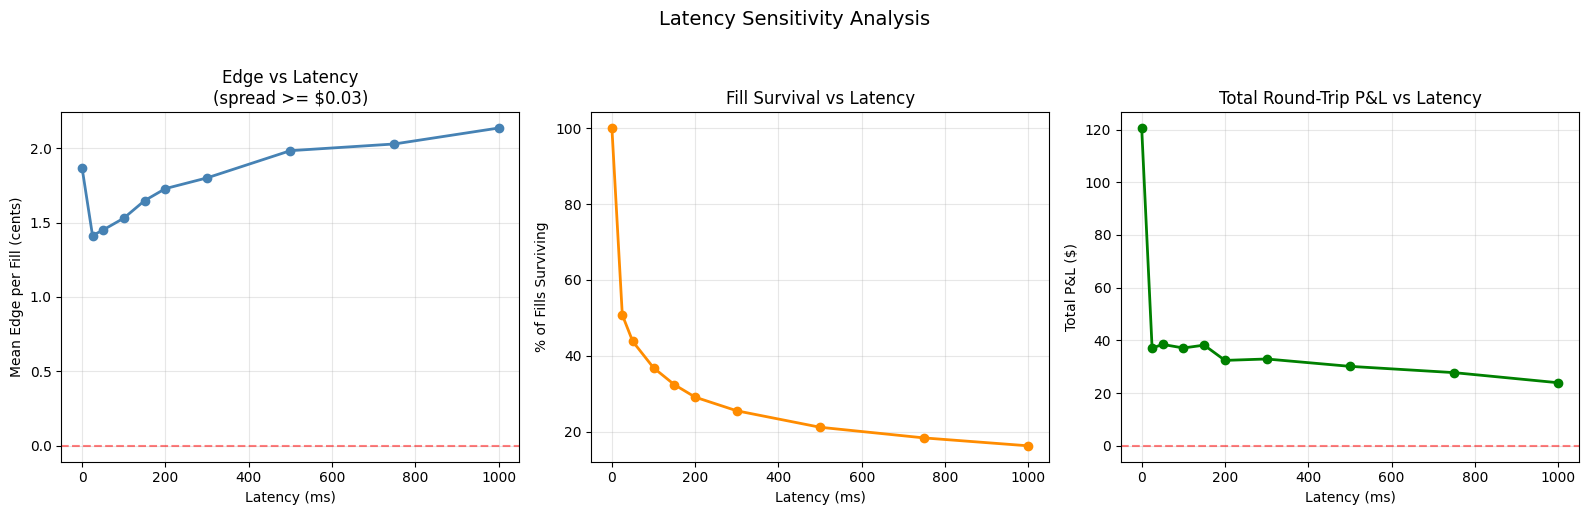


Edge remains positive up to 1000ms latency.
  At 200ms: edge=$0.0173
  Round-trip P&L positive up to 1000ms.


In [48]:
# --- Latency sensitivity plots ---
if latency_sweep:
    ls = pd.DataFrame(latency_sweep)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 1. Edge vs latency
    ax = axes[0]
    ax.plot(ls["latency_ms"], ls["edge_10s"] * 100, "o-", color="steelblue", linewidth=2)
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Mean Edge per Fill (cents)")
    ax.set_title("Edge vs Latency\n(spread >= $0.03)")
    ax.grid(True, alpha=0.3)
    
    # 2. Fills surviving vs latency
    ax = axes[1]
    ax.plot(ls["latency_ms"], ls["pct_kept"] * 100, "o-", color="darkorange", linewidth=2)
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("% of Fills Surviving")
    ax.set_title("Fill Survival vs Latency")
    ax.grid(True, alpha=0.3)
    
    # 3. Total P&L vs latency
    ax = axes[2]
    ax.plot(ls["latency_ms"], ls["total_pnl"], "o-", color="green", linewidth=2)
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Total P&L ($)")
    ax.set_title("Total Round-Trip P&L vs Latency")
    ax.grid(True, alpha=0.3)
    
    plt.suptitle("Latency Sensitivity Analysis", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Key thresholds
    positive_edge = ls[ls["edge_10s"] > 0]
    if not positive_edge.empty:
        max_latency = positive_edge["latency_ms"].max()
        print(f"\nEdge remains positive up to {max_latency}ms latency.")
        print(f"  At 200ms: edge=${ls[ls['latency_ms']==200]['edge_10s'].values[0]:.4f}" 
              if 200 in ls['latency_ms'].values else "")
    
    profitable_rts = ls[ls["total_pnl"] > 0]
    if not profitable_rts.empty:
        max_profitable = profitable_rts["latency_ms"].max()
        print(f"  Round-trip P&L positive up to {max_profitable}ms.")
    else:
        print(f"  Round-trip P&L never positive in sweep.")
else:
    print("No latency sweep data.")